In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/heart-failure-prediction/heart.csv


In [2]:
df = pd.read_csv("/kaggle/input/heart-failure-prediction/heart.csv")

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
col_obj = []
col_num = []

for col in df.columns:
    if df[col].dtype == 'object':
        col_obj.append(col)
    else:
        col_num.append(col)

# Dados e gráficos relacionadas as colunas objetivas

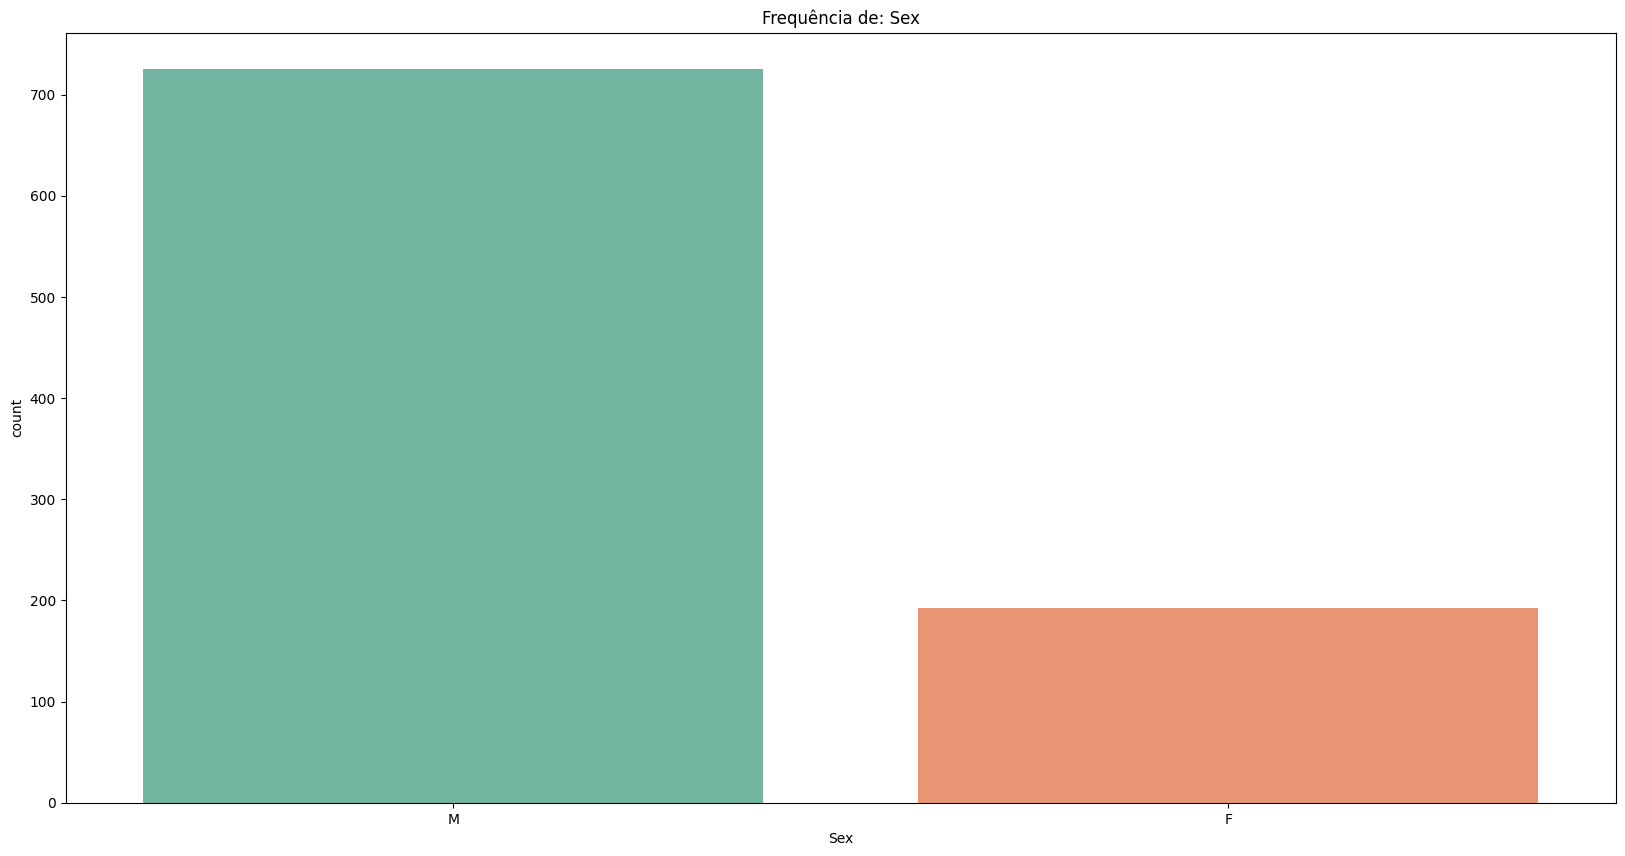

Frequência da coluna Sex:
  Sex  Frequência
0   M         725
1   F         193


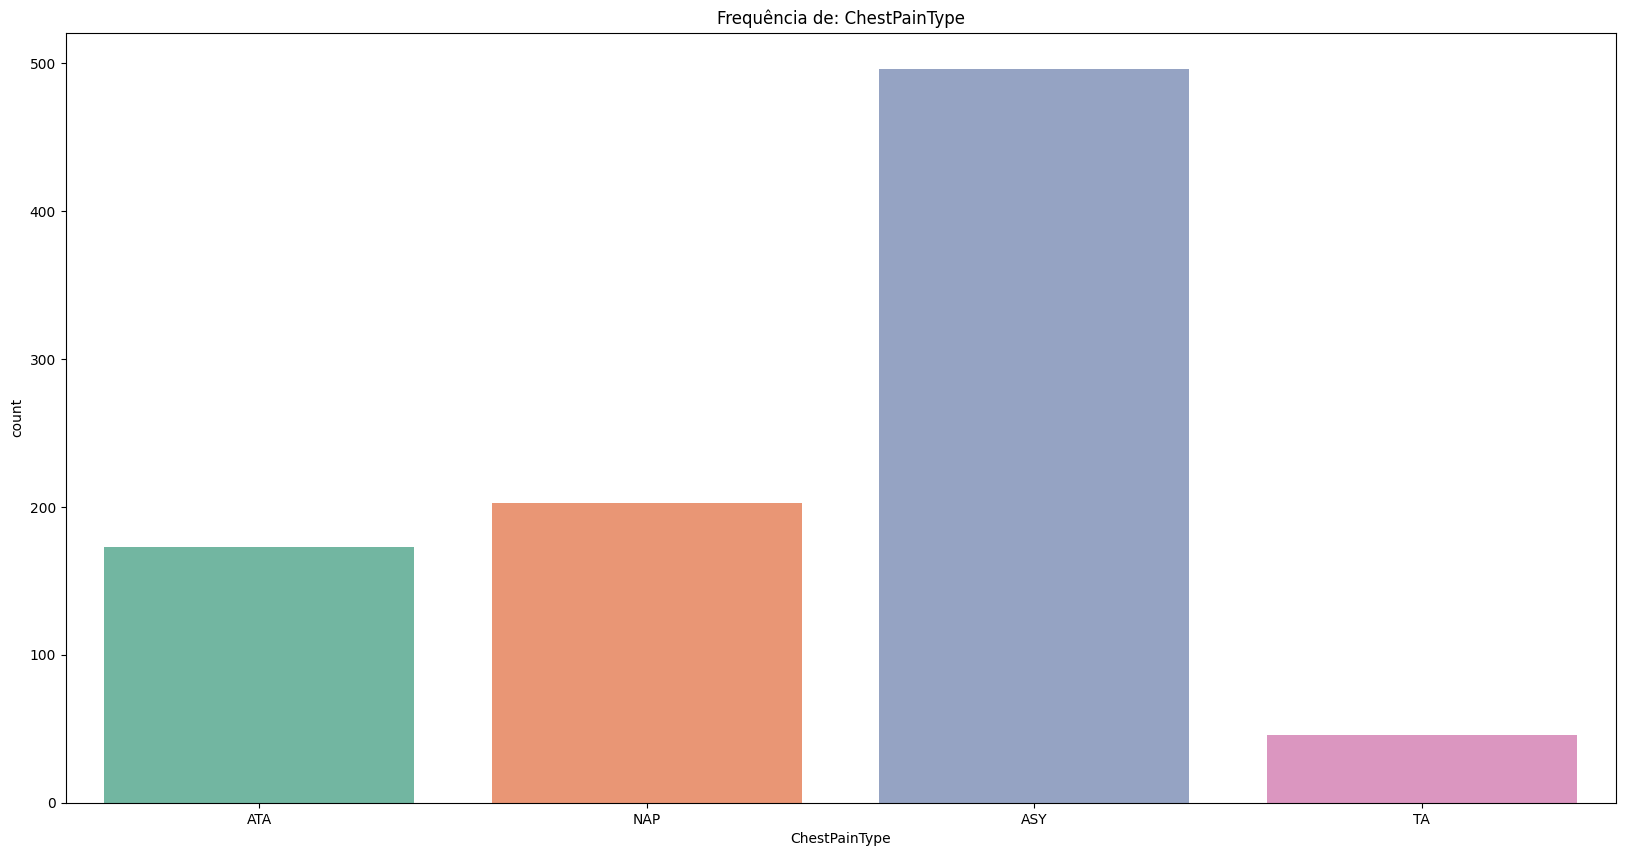

Frequência da coluna ChestPainType:
  ChestPainType  Frequência
0           ASY         496
1           NAP         203
2           ATA         173
3            TA          46


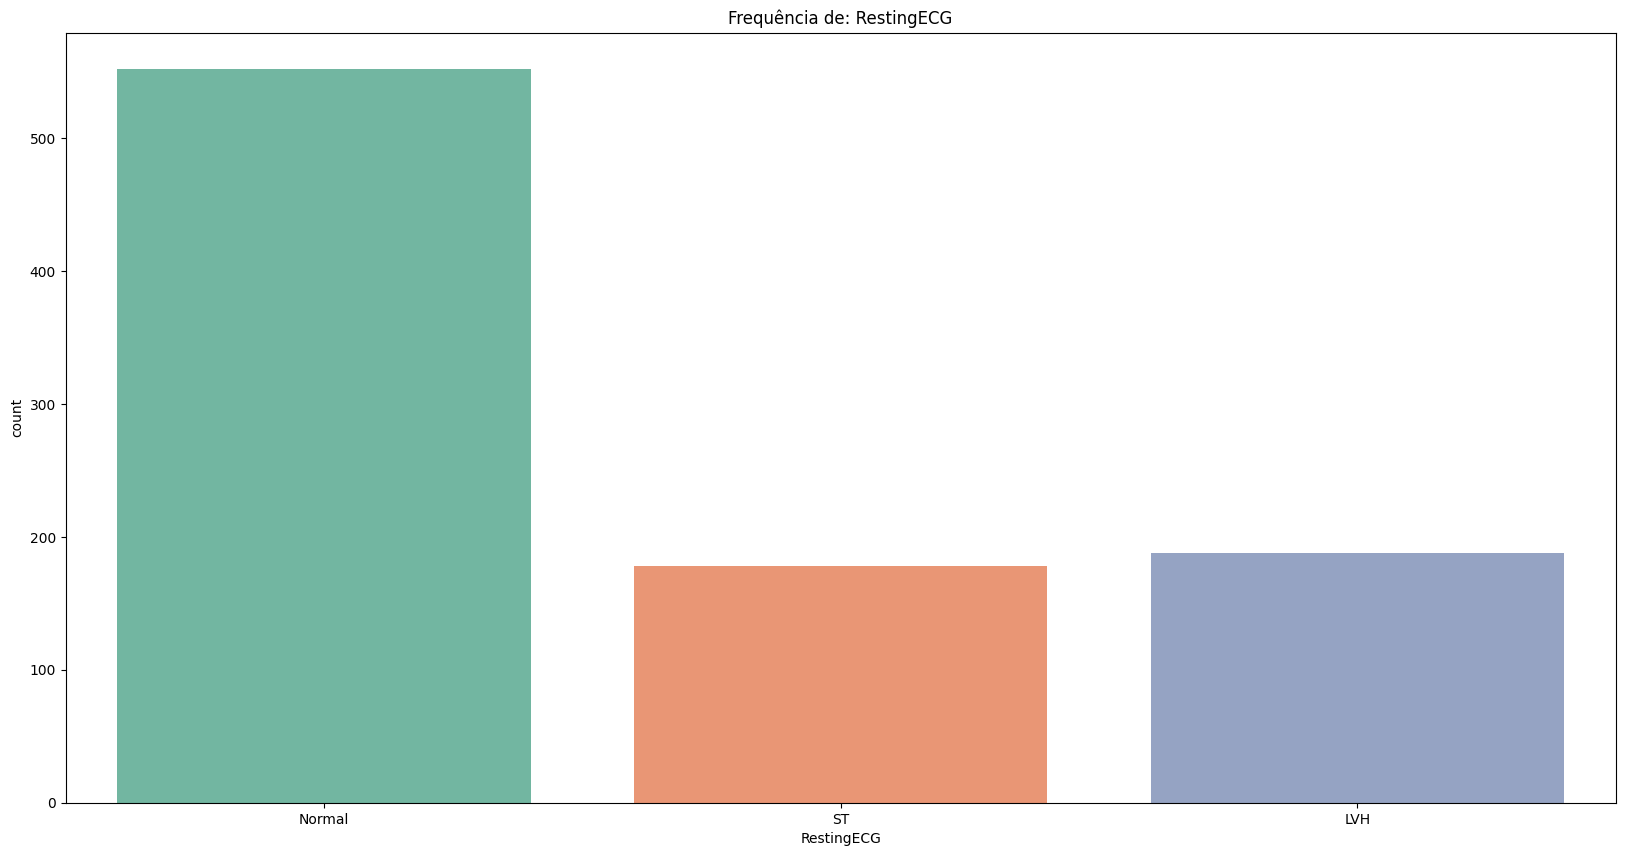

Frequência da coluna RestingECG:
  RestingECG  Frequência
0     Normal         552
1        LVH         188
2         ST         178


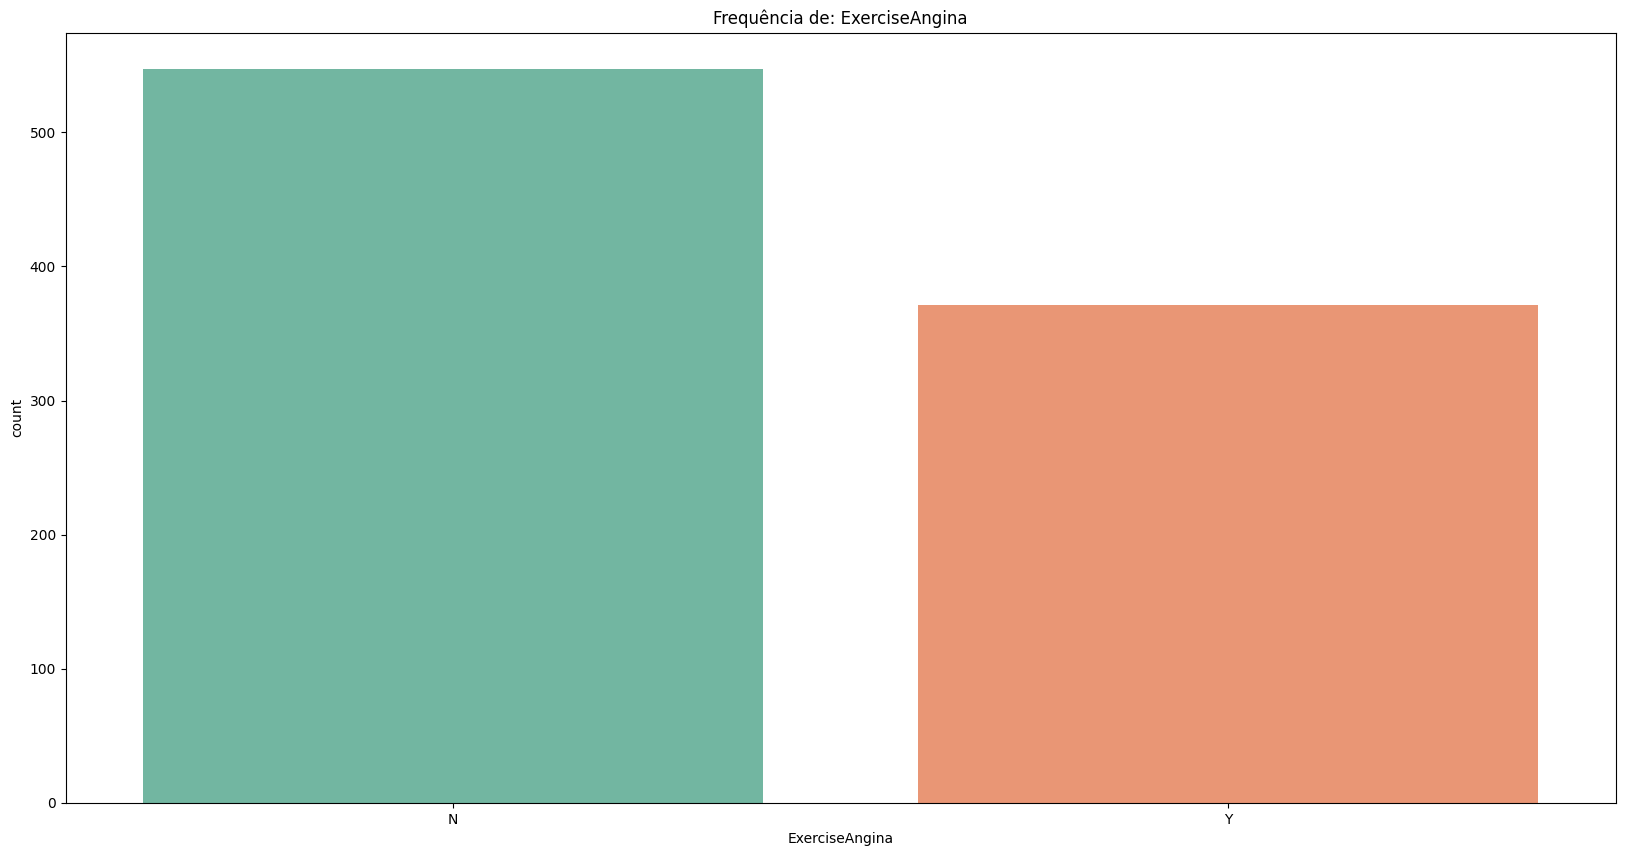

Frequência da coluna ExerciseAngina:
  ExerciseAngina  Frequência
0              N         547
1              Y         371


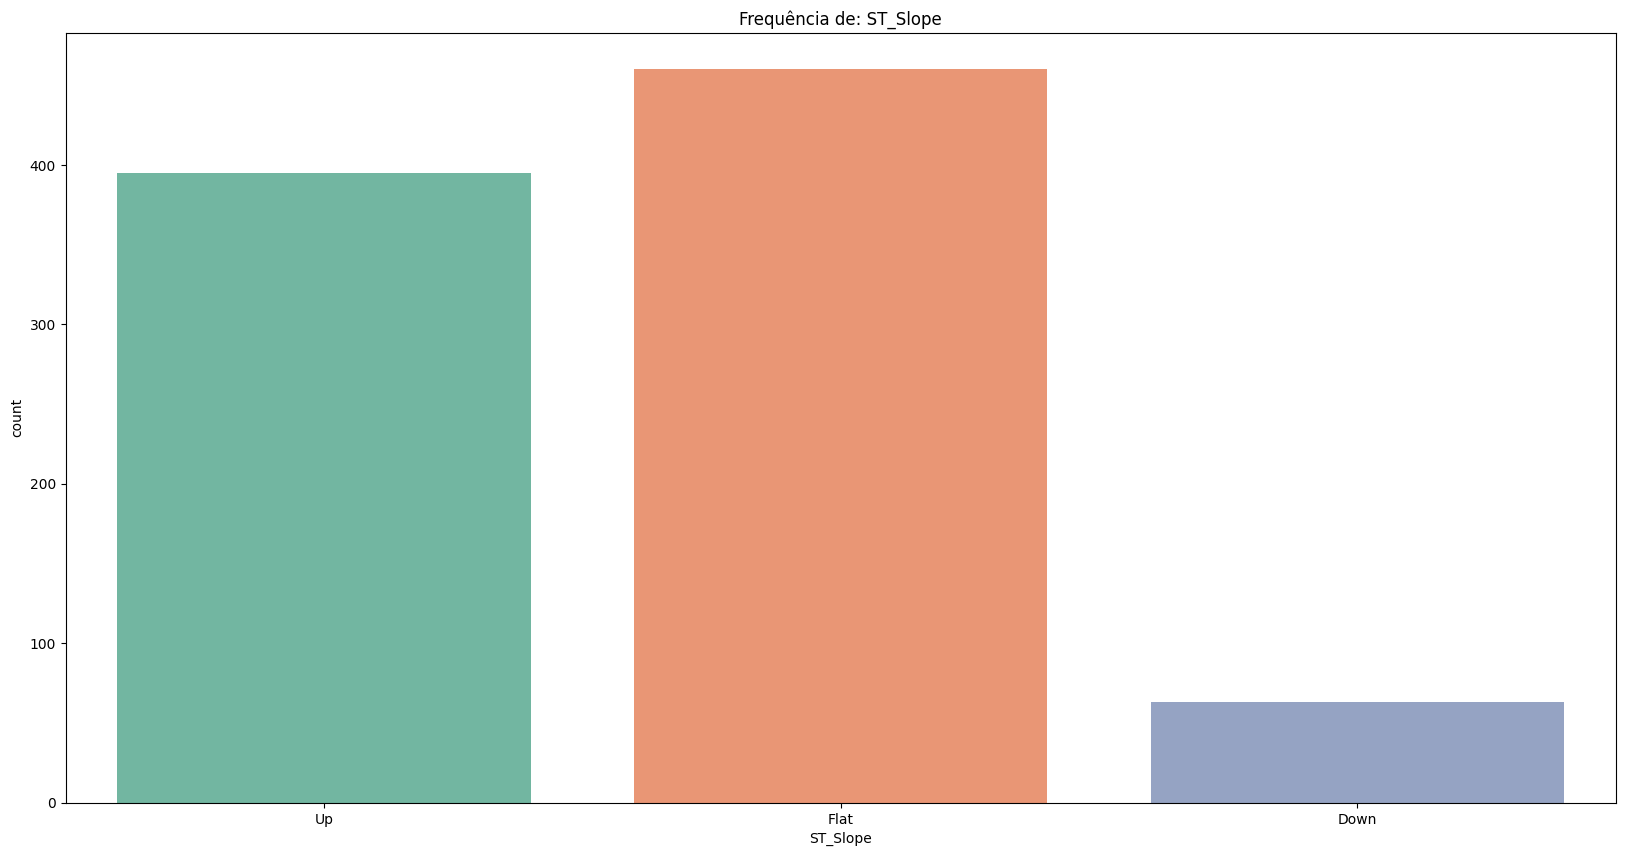

Frequência da coluna ST_Slope:
  ST_Slope  Frequência
0     Flat         460
1       Up         395
2     Down          63


In [6]:
pular_obj = ['Cholesterol']

for col in col_obj:
    if col in pular_obj:
        continue
    plt.figure(figsize=(20,10))
    plt.title(f"Frequência de: {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Frequência")
    sns.countplot(data=df, x=col, palette="Set2")
    plt.xticks(rotation=0)
    plt.show()  # Exibe o gráfico
    # Conta a frequência dos valores na coluna
    qtd = df[col].value_counts().reset_index(name='Frequência')
    qtd.columns = [col, 'Frequência']
    # Imprime as frequências
    print(f'Frequência da coluna {col}:')
    print(qtd)

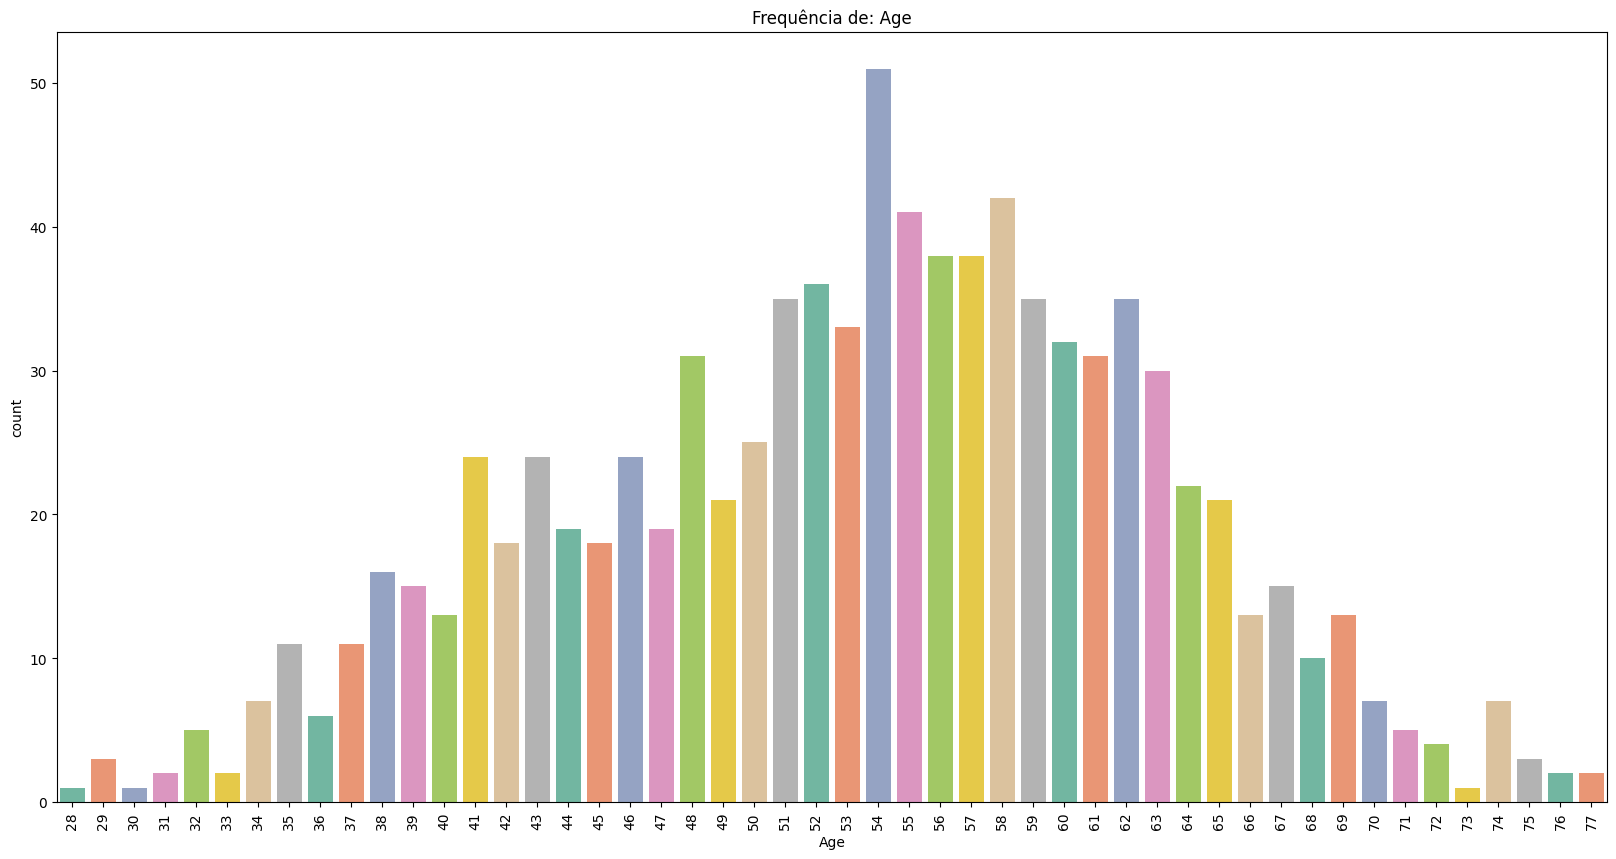

Frequência da coluna Age:
    Age  Frequência
0    54          51
1    58          42
2    55          41
3    56          38
4    57          38
5    52          36
6    51          35
7    59          35
8    62          35
9    53          33
10   60          32
11   48          31
12   61          31
13   63          30
14   50          25
15   46          24
16   41          24
17   43          24
18   64          22
19   65          21
20   49          21
21   47          19
22   44          19
23   42          18
24   45          18
25   38          16
26   67          15
27   39          15
28   66          13
29   69          13
30   40          13
31   35          11
32   37          11
33   68          10
34   34           7
35   74           7
36   70           7
37   36           6
38   71           5
39   32           5
40   72           4
41   29           3
42   75           3
43   33           2
44   77           2
45   76           2
46   31           2
47   30       

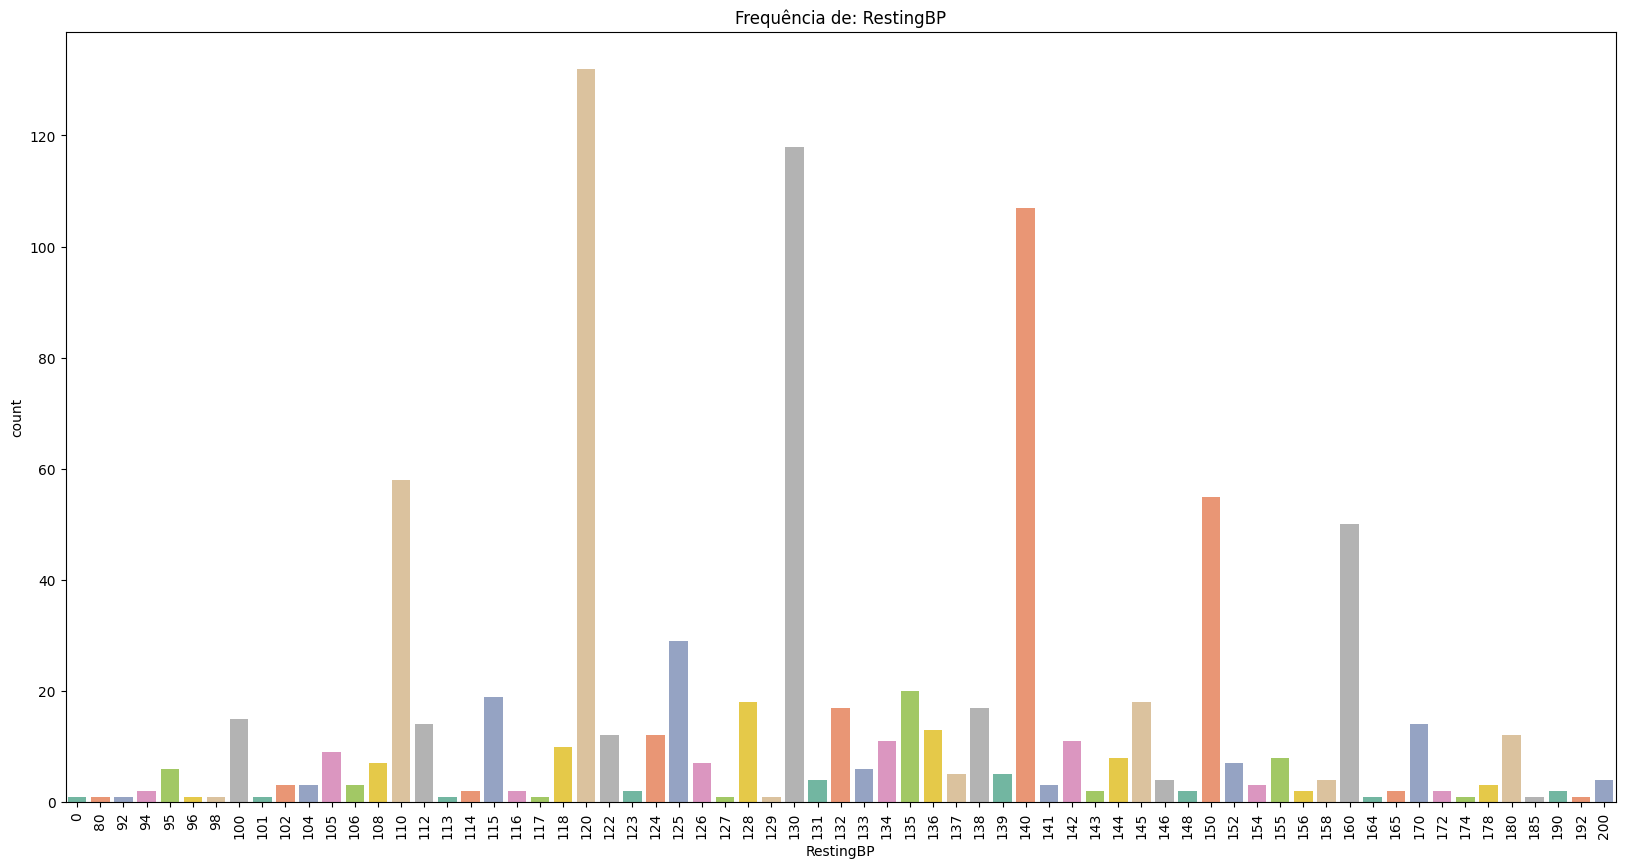

Frequência da coluna RestingBP:
    RestingBP  Frequência
0         120         132
1         130         118
2         140         107
3         110          58
4         150          55
..        ...         ...
62        185           1
63         98           1
64         92           1
65        113           1
66        164           1

[67 rows x 2 columns]


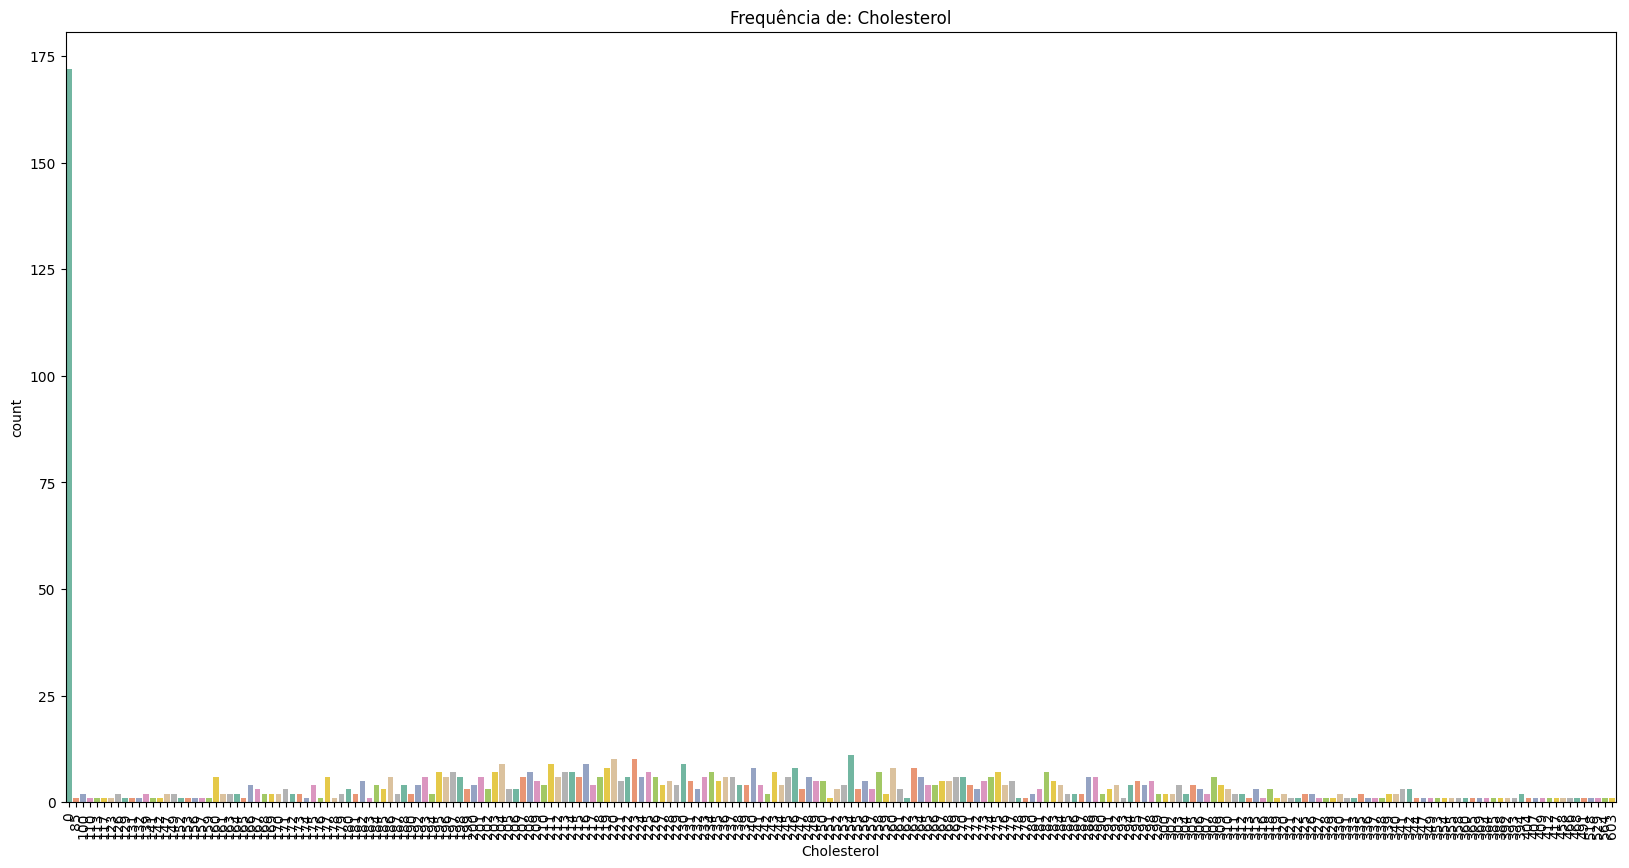

Frequência da coluna Cholesterol:
     Cholesterol  Frequência
0              0         172
1            254          11
2            223          10
3            220          10
4            230           9
..           ...         ...
217          392           1
218          316           1
219          153           1
220          466           1
221          131           1

[222 rows x 2 columns]


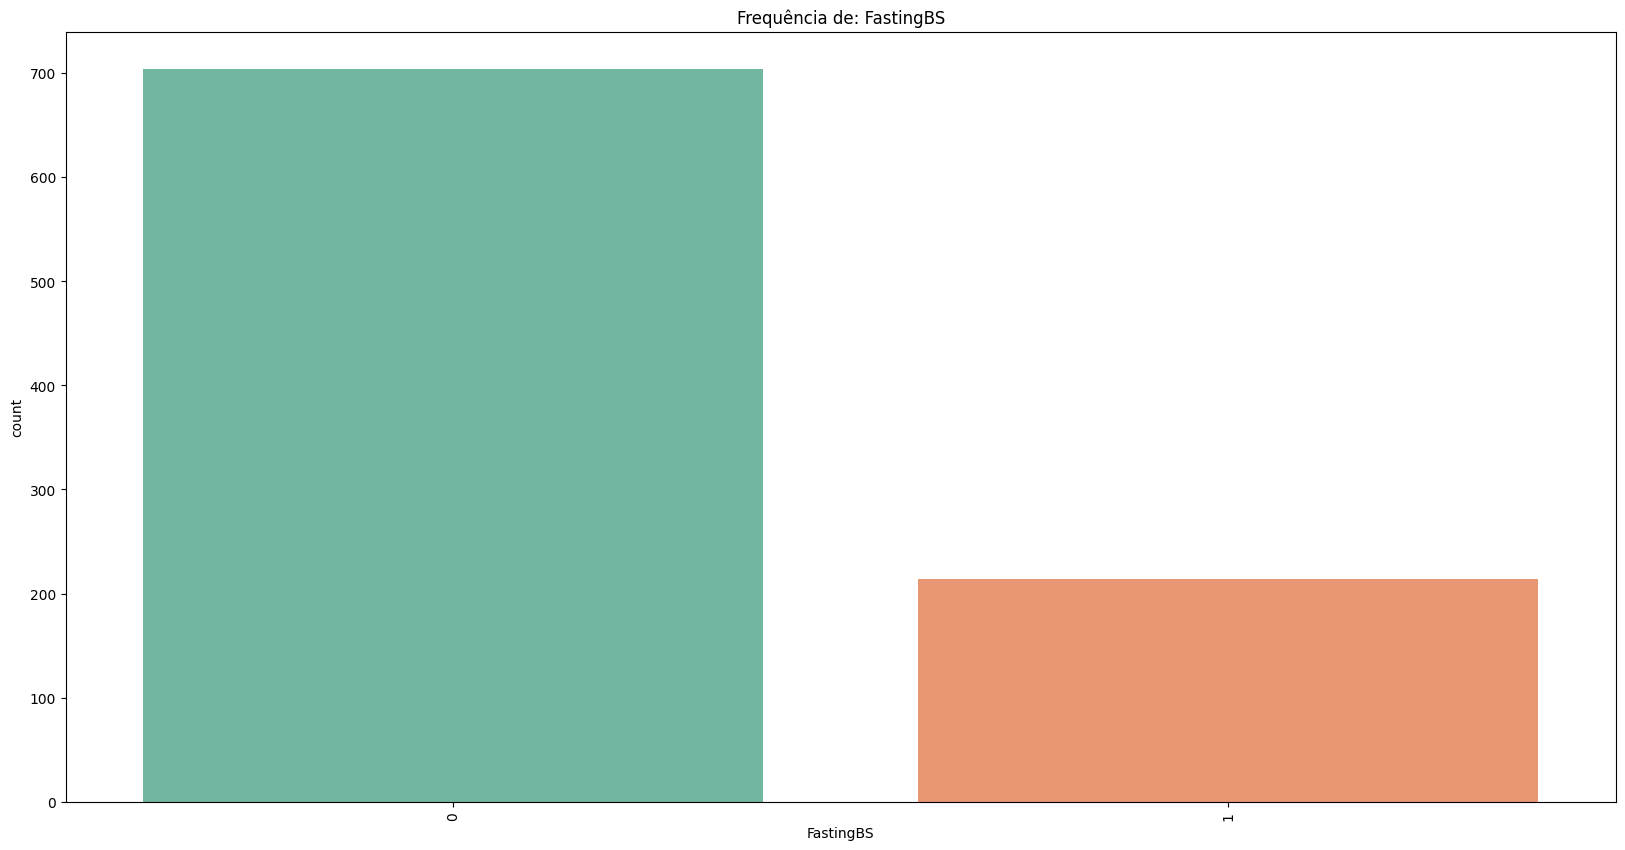

Frequência da coluna FastingBS:
   FastingBS  Frequência
0          0         704
1          1         214


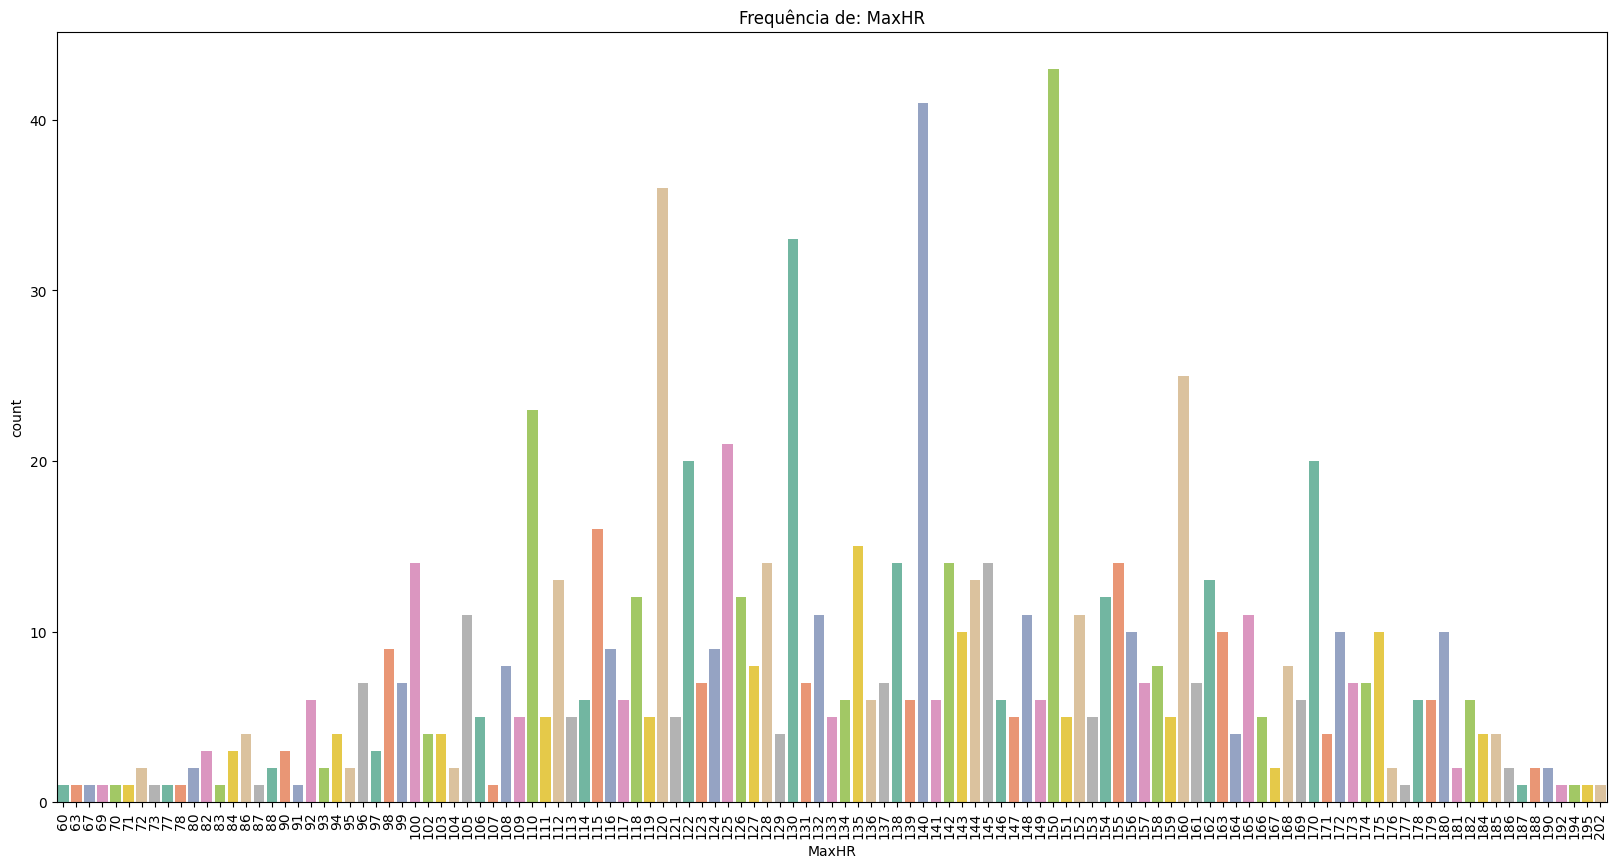

Frequência da coluna MaxHR:
     MaxHR  Frequência
0      150          43
1      140          41
2      120          36
3      130          33
4      160          25
..     ...         ...
114     63           1
115     83           1
116     60           1
117     78           1
118    202           1

[119 rows x 2 columns]


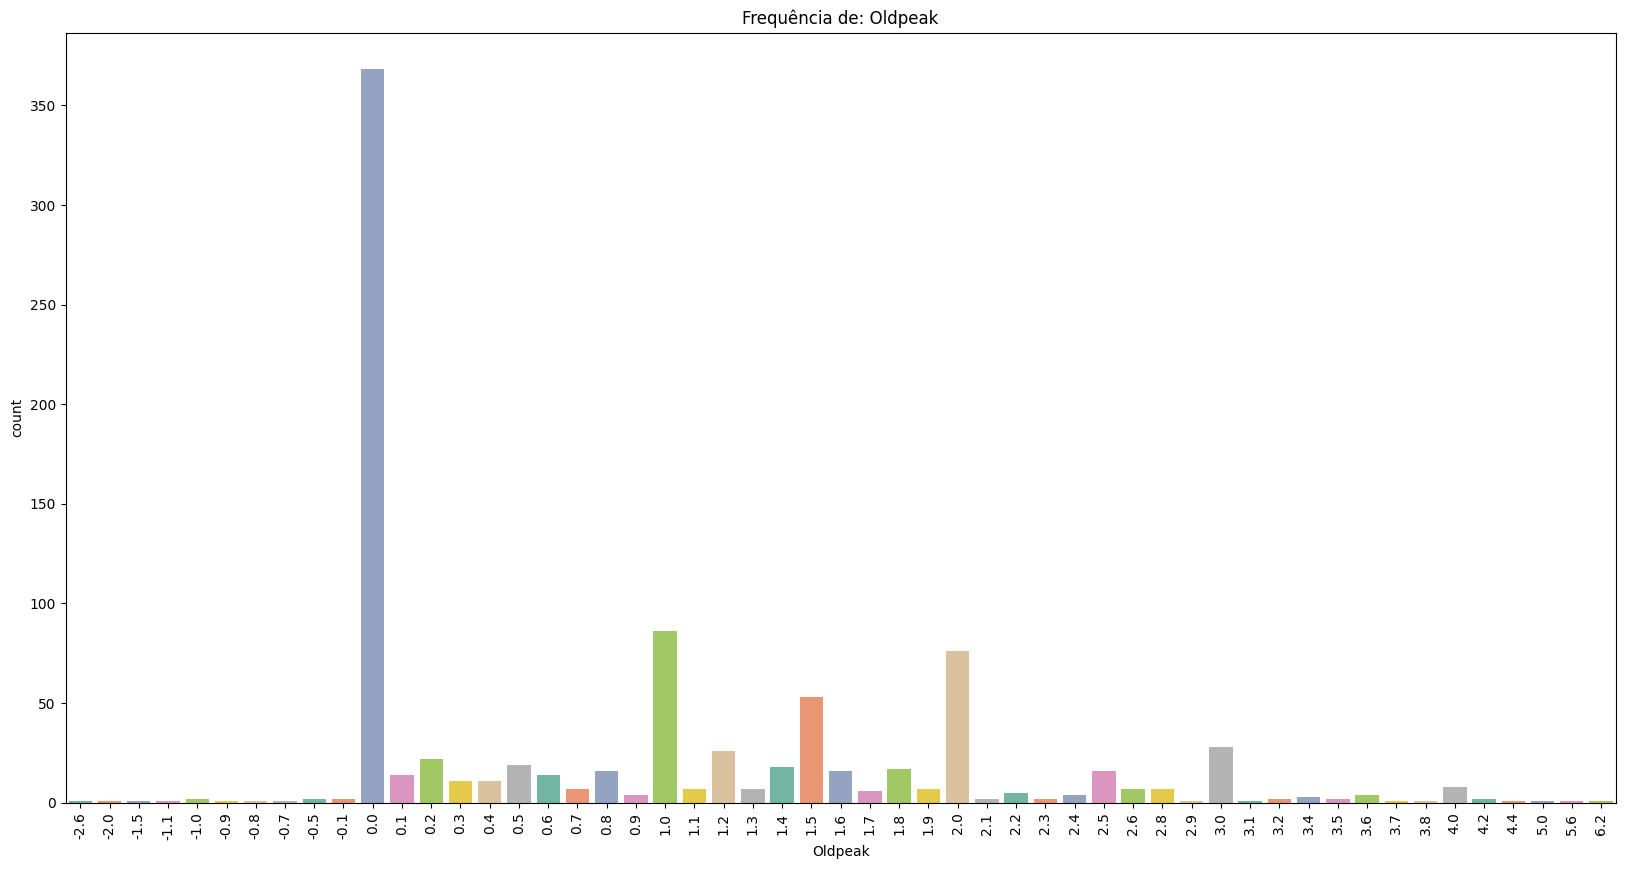

Frequência da coluna Oldpeak:
    Oldpeak  Frequência
0       0.0         368
1       1.0          86
2       2.0          76
3       1.5          53
4       3.0          28
5       1.2          26
6       0.2          22
7       0.5          19
8       1.4          18
9       1.8          17
10      2.5          16
11      0.8          16
12      1.6          16
13      0.1          14
14      0.6          14
15      0.4          11
16      0.3          11
17      4.0           8
18      0.7           7
19      2.8           7
20      1.9           7
21      1.3           7
22      2.6           7
23      1.1           7
24      1.7           6
25      2.2           5
26      0.9           4
27      2.4           4
28      3.6           4
29      3.4           3
30      4.2           2
31      3.5           2
32     -0.5           2
33      2.3           2
34      3.2           2
35      2.1           2
36     -1.0           2
37     -0.1           2
38      5.6           1
39      2.

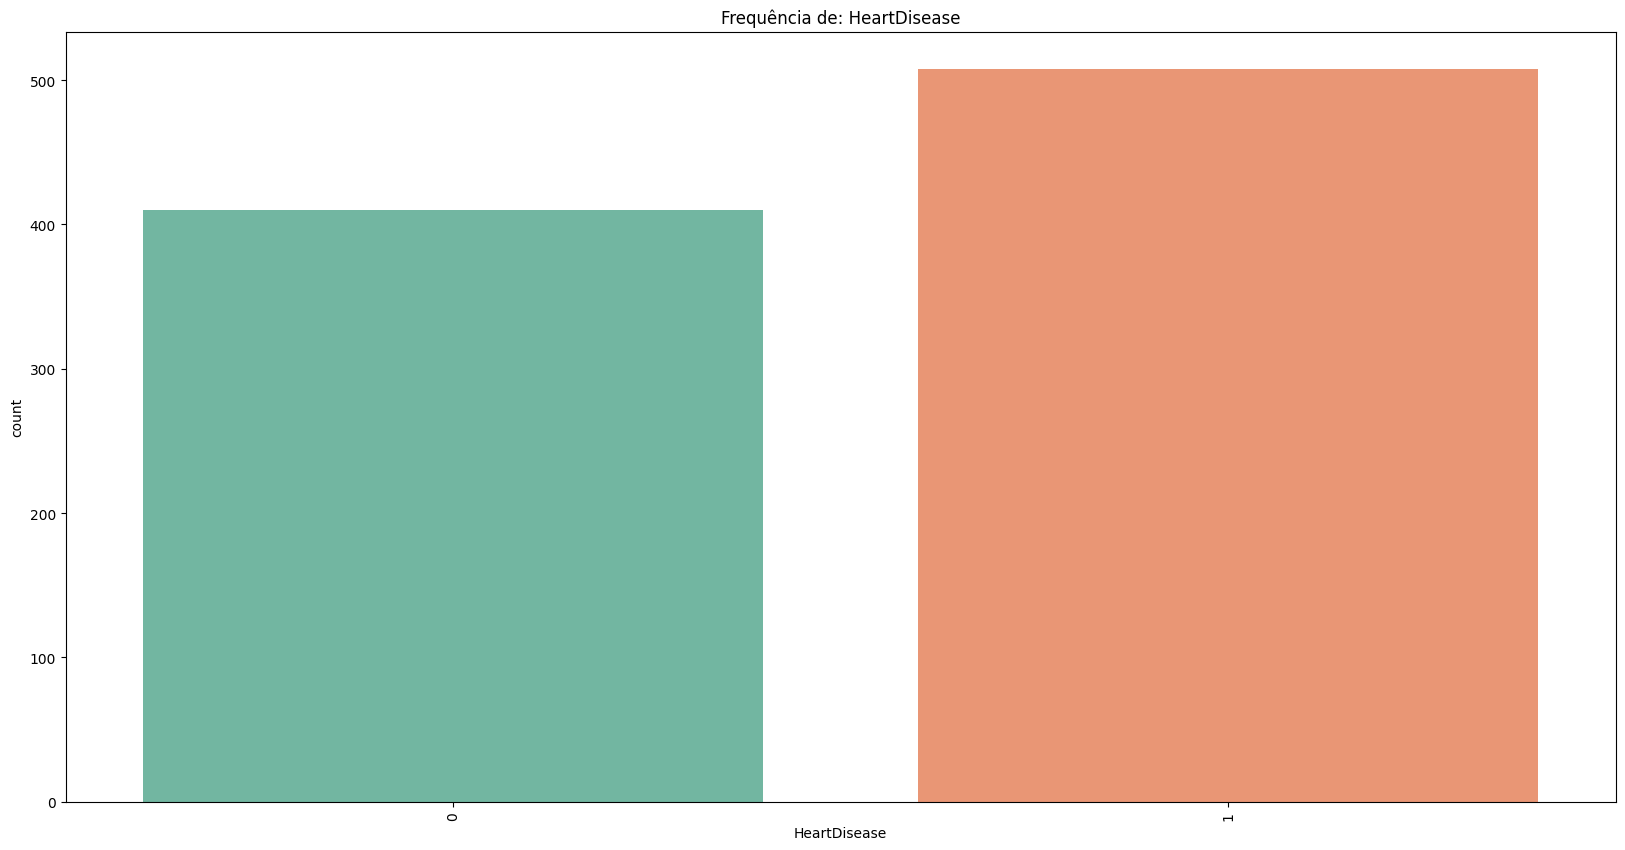

Frequência da coluna HeartDisease:
   HeartDisease  Frequência
0             1         508
1             0         410


In [7]:
pular_num = []

for col in col_num:
    if col in pular_num:
        continue
    plt.figure(figsize=(20,10))
    plt.title(f"Frequência de: {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Frequência")
    sns.countplot(data=df, x=col, palette="Set2")
    plt.xticks(rotation=90)
    plt.show()  # Exibe o gráfico
    # Conta a frequência dos valores na coluna
    qtd = df[col].value_counts().reset_index(name='Frequência')
    qtd.columns = [col, 'Frequência']
    # Imprime as frequências
    print(f'Frequência da coluna {col}:')
    print(qtd)

# Dados e gráficos relacionadas as colunas numericas

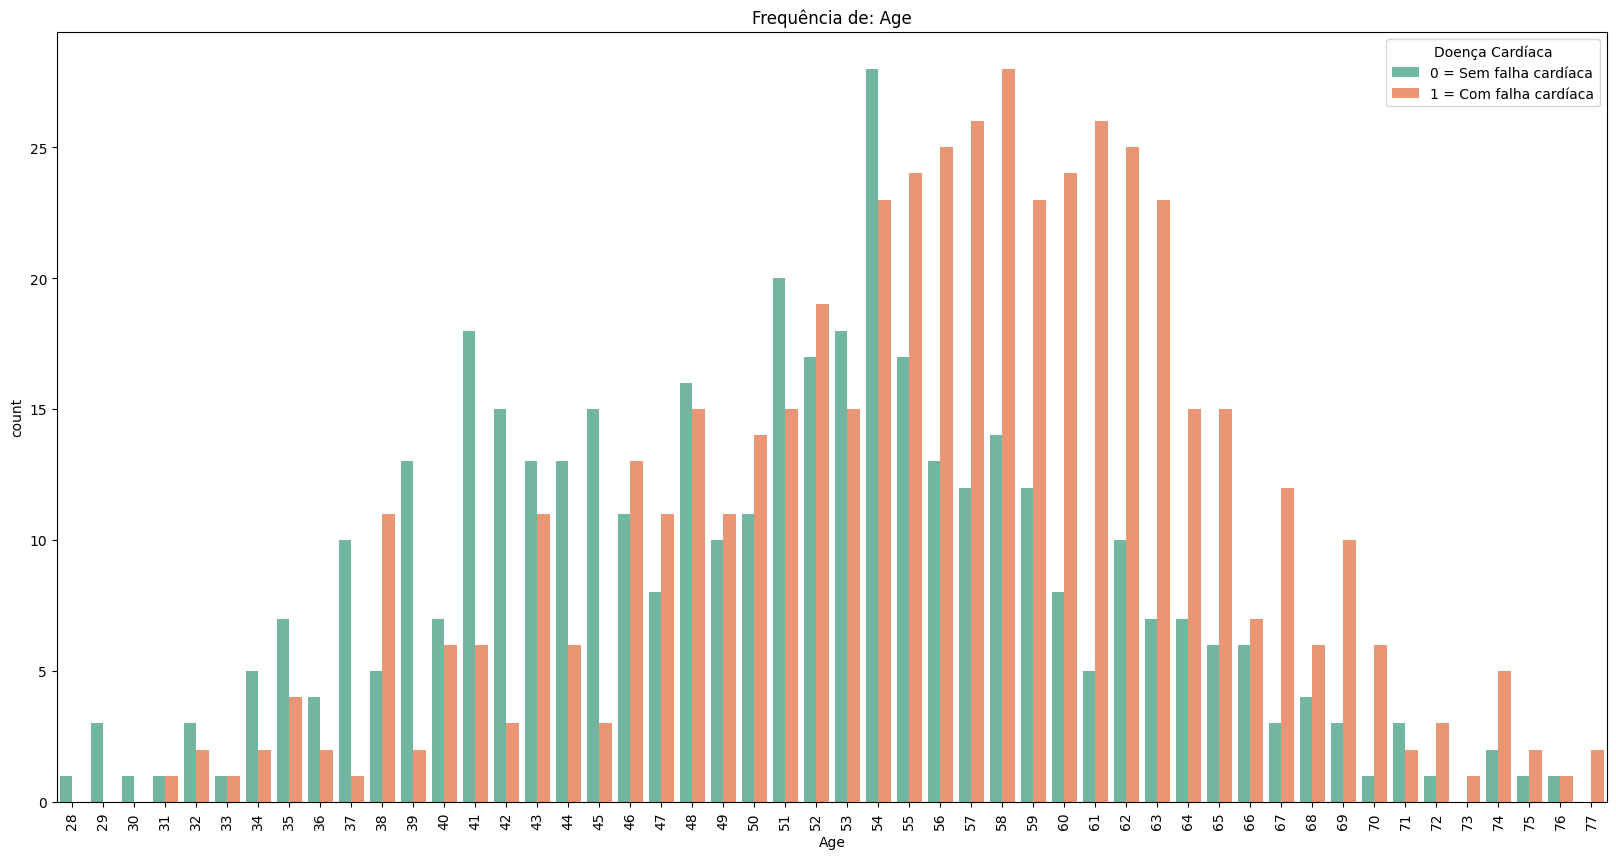

Frequência da coluna Age:
    Age  HeartDisease  Frequência
0    28             0           1
1    29             0           3
2    30             0           1
3    31             0           1
4    31             1           1
..  ...           ...         ...
90   75             0           1
91   75             1           2
92   76             0           1
93   76             1           1
94   77             1           2

[95 rows x 3 columns]


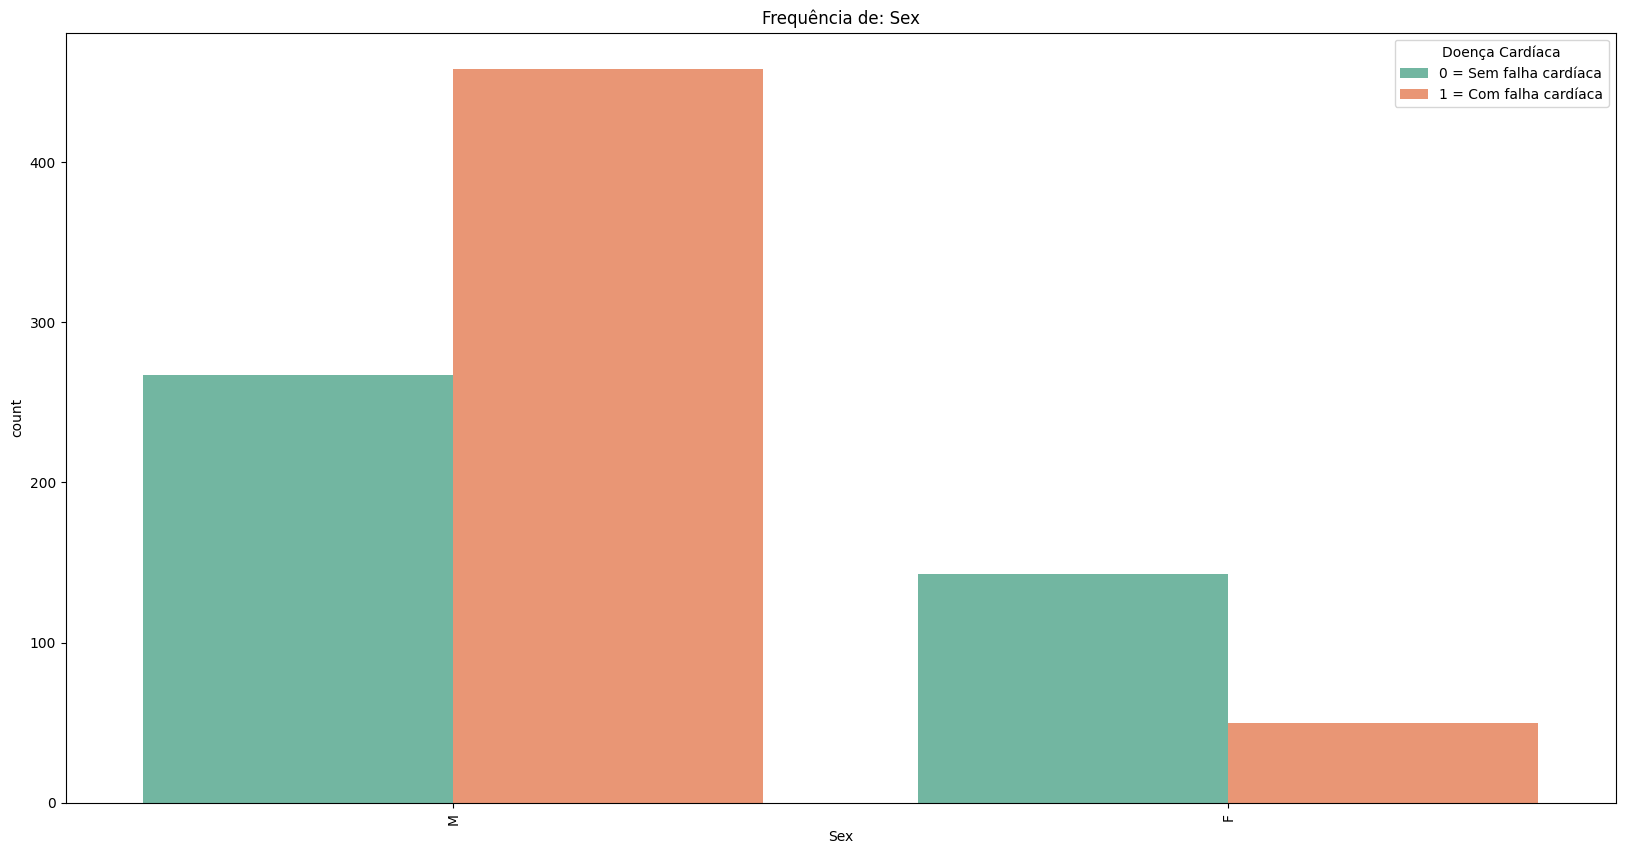

Frequência da coluna Sex:
  Sex  HeartDisease  Frequência
0   F             0         143
1   F             1          50
2   M             0         267
3   M             1         458


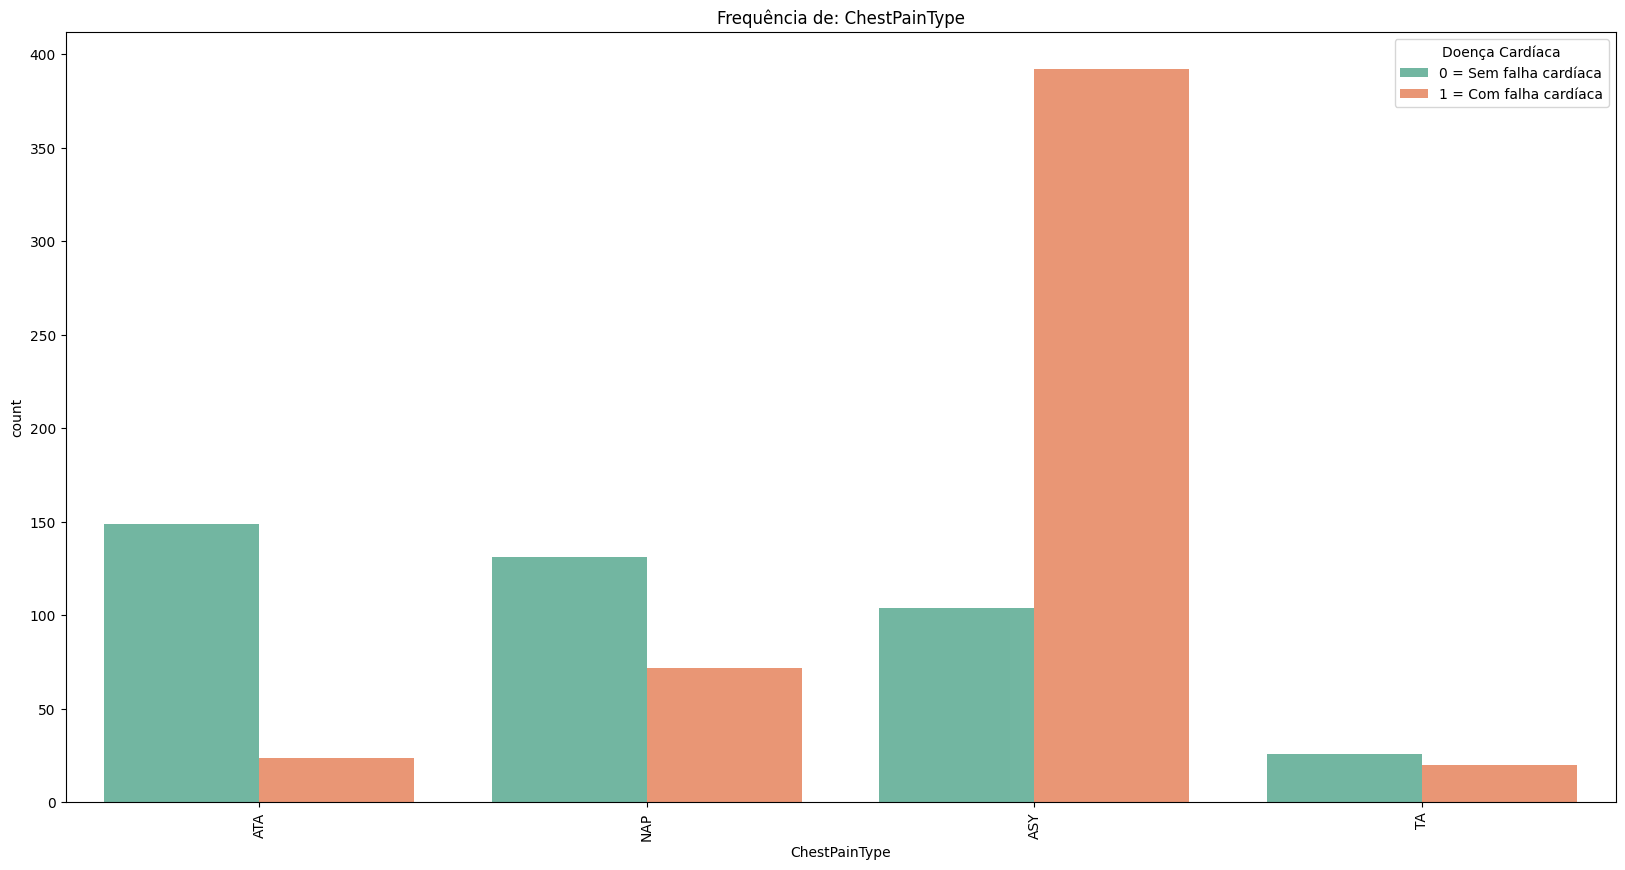

Frequência da coluna ChestPainType:
  ChestPainType  HeartDisease  Frequência
0           ASY             0         104
1           ASY             1         392
2           ATA             0         149
3           ATA             1          24
4           NAP             0         131
5           NAP             1          72
6            TA             0          26
7            TA             1          20


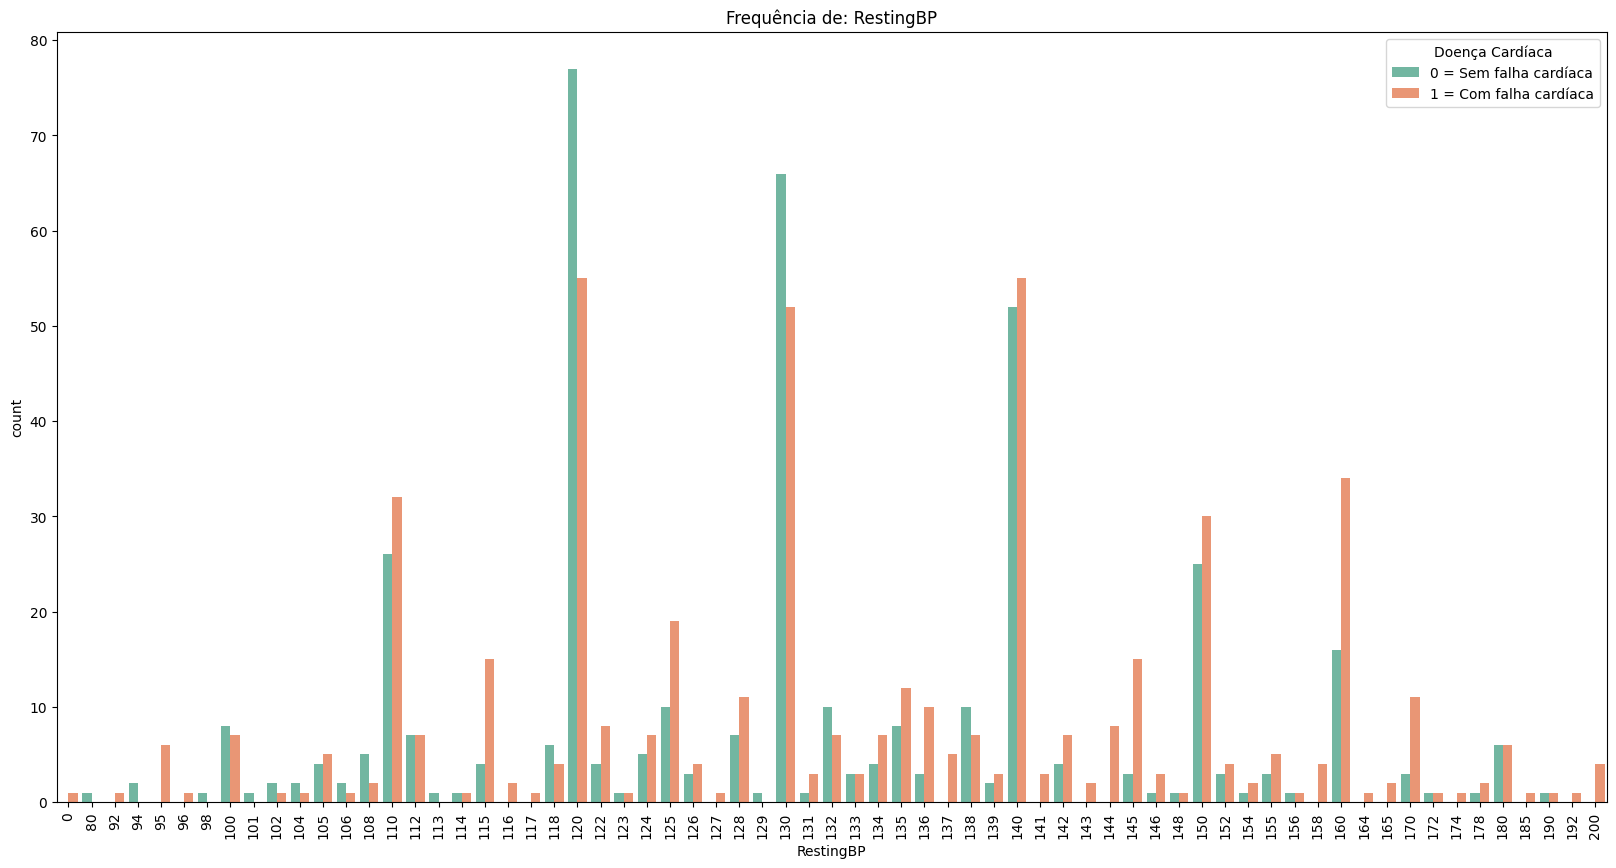

Frequência da coluna RestingBP:
     RestingBP  HeartDisease  Frequência
0            0             1           1
1           80             0           1
2           92             1           1
3           94             0           2
4           95             1           6
..         ...           ...         ...
105        185             1           1
106        190             0           1
107        190             1           1
108        192             1           1
109        200             1           4

[110 rows x 3 columns]


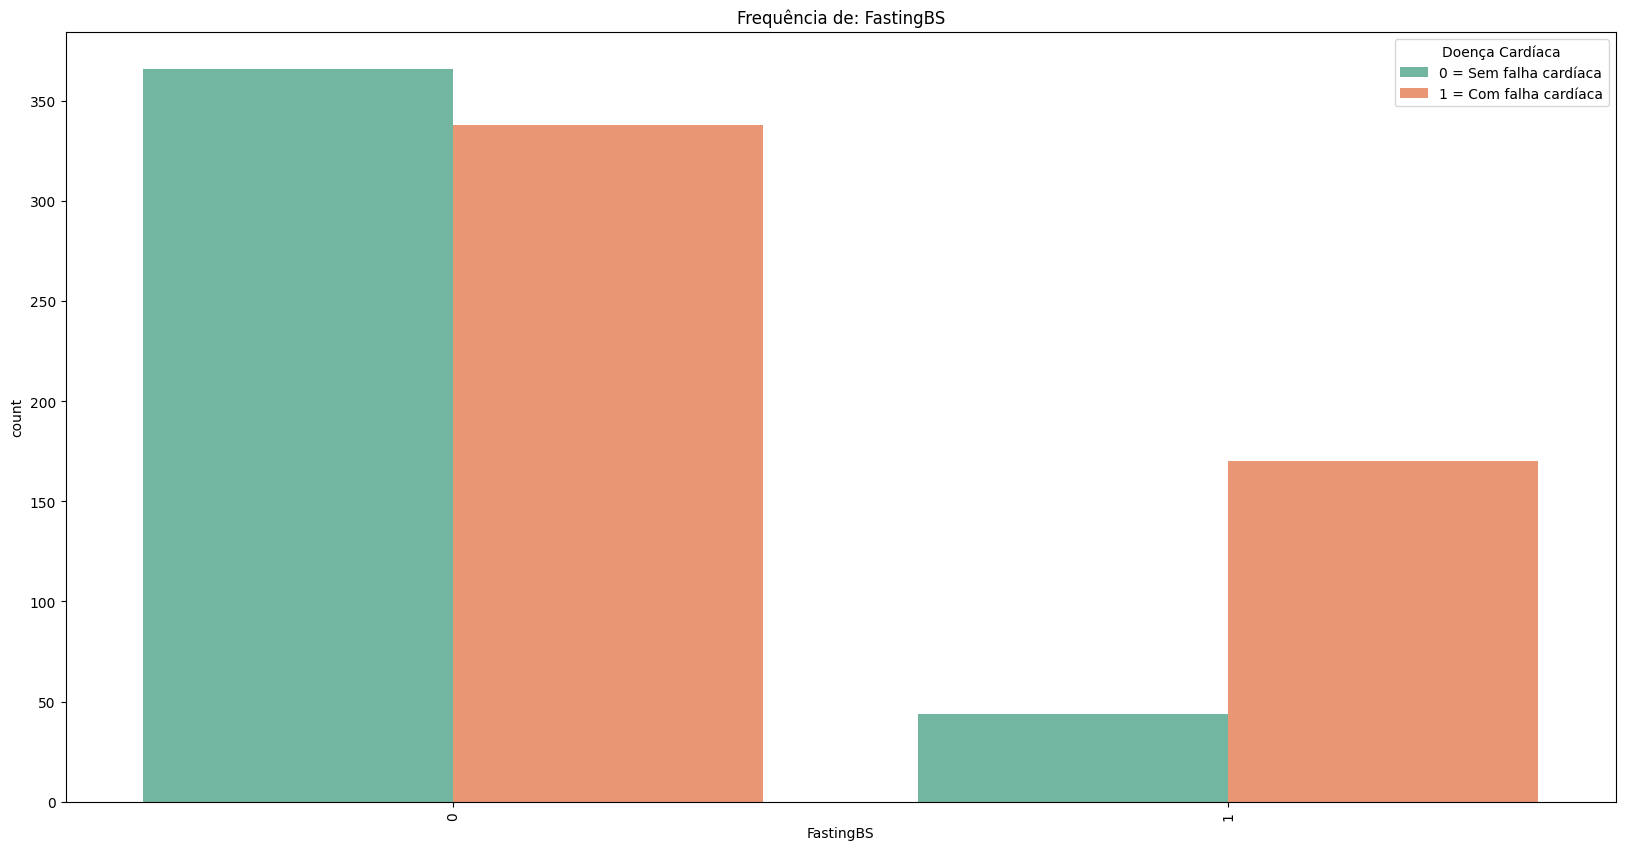

Frequência da coluna FastingBS:
   FastingBS  HeartDisease  Frequência
0          0             0         366
1          0             1         338
2          1             0          44
3          1             1         170


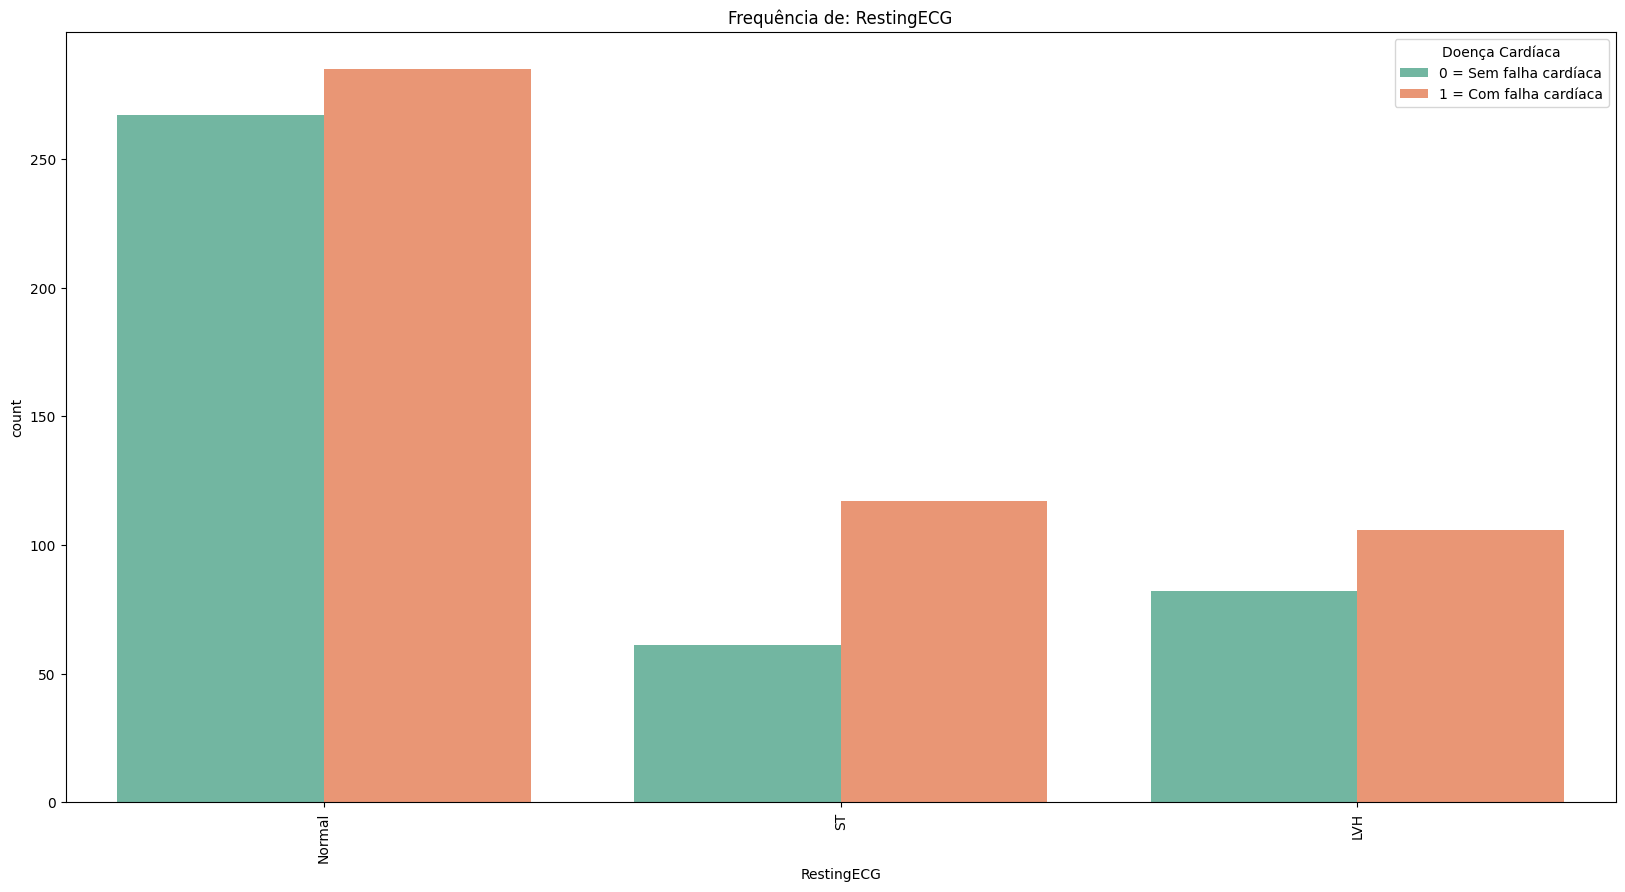

Frequência da coluna RestingECG:
  RestingECG  HeartDisease  Frequência
0        LVH             0          82
1        LVH             1         106
2     Normal             0         267
3     Normal             1         285
4         ST             0          61
5         ST             1         117


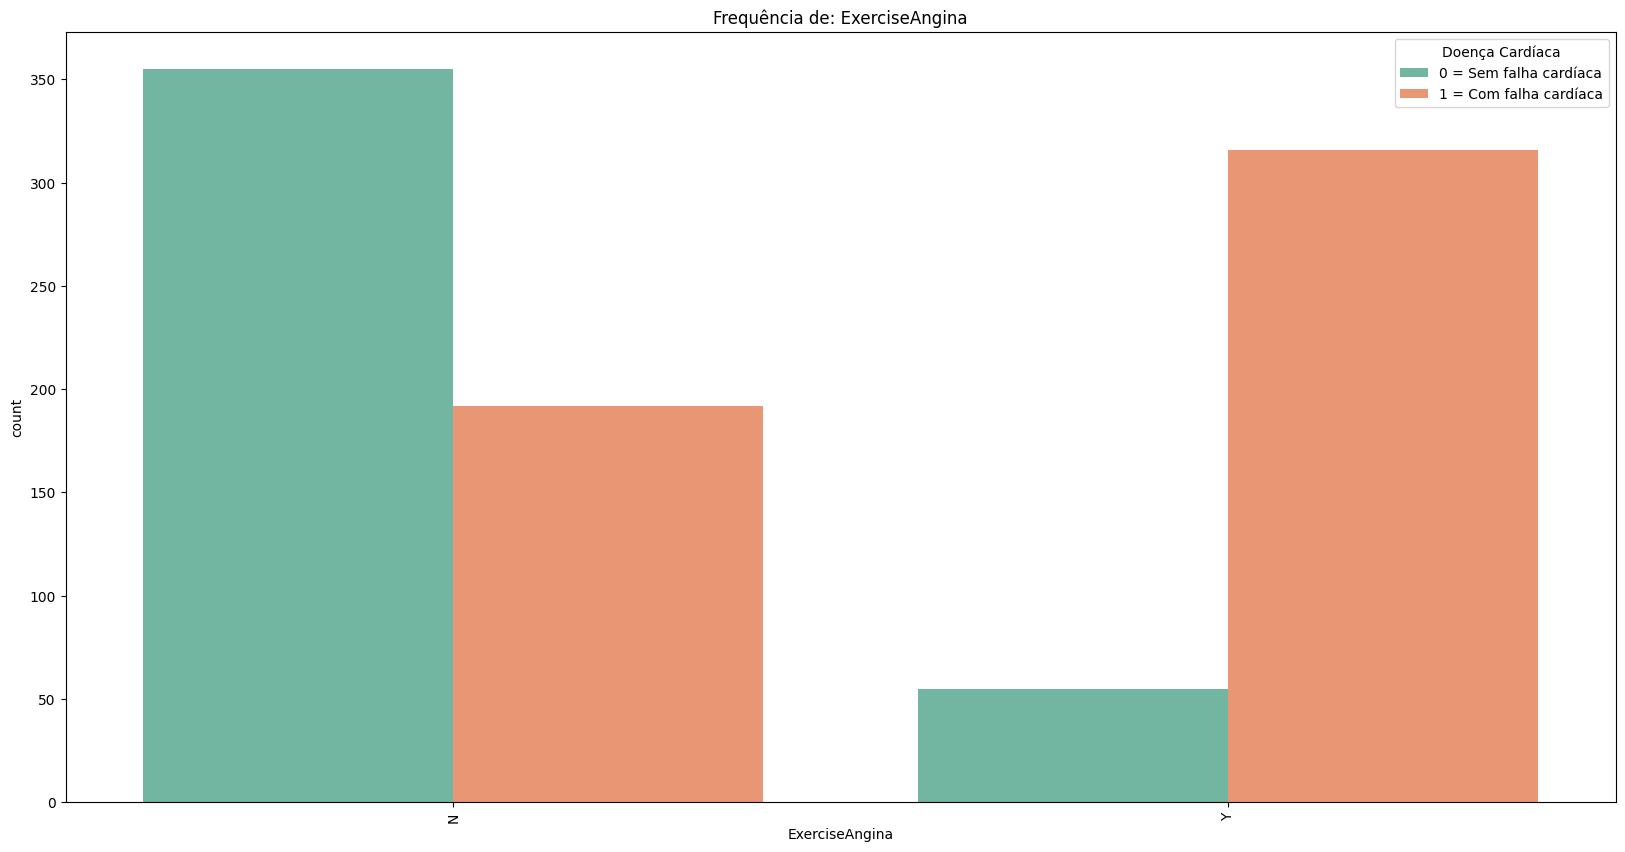

Frequência da coluna ExerciseAngina:
  ExerciseAngina  HeartDisease  Frequência
0              N             0         355
1              N             1         192
2              Y             0          55
3              Y             1         316


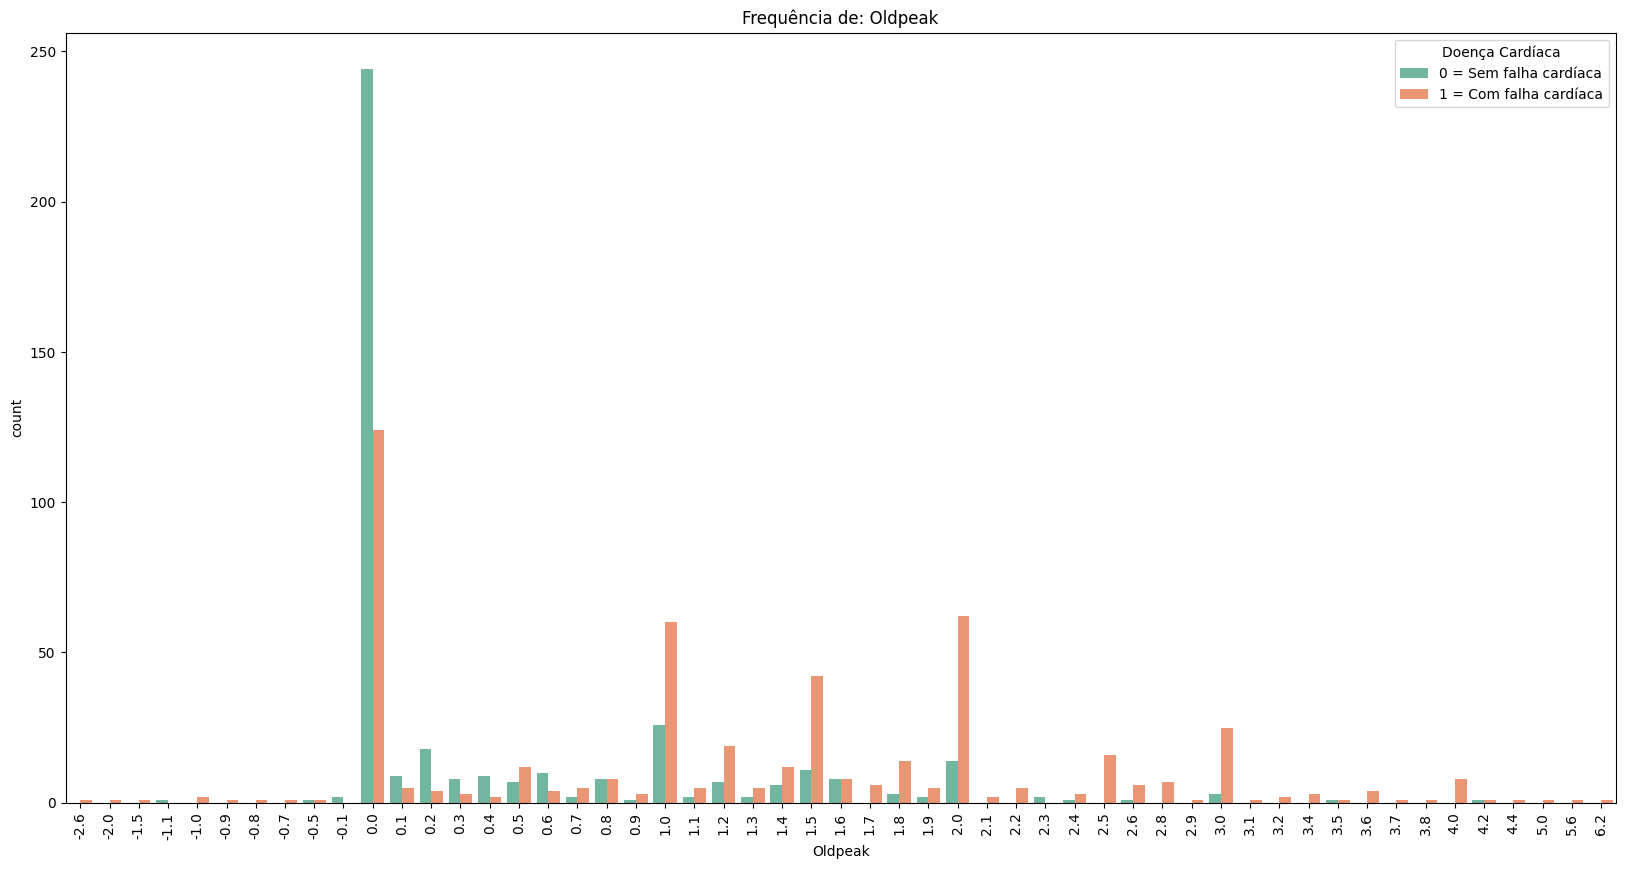

Frequência da coluna Oldpeak:
    Oldpeak  HeartDisease  Frequência
0      -2.6             1           1
1      -2.0             1           1
2      -1.5             1           1
3      -1.1             0           1
4      -1.0             1           2
..      ...           ...         ...
74      4.2             1           1
75      4.4             1           1
76      5.0             1           1
77      5.6             1           1
78      6.2             1           1

[79 rows x 3 columns]


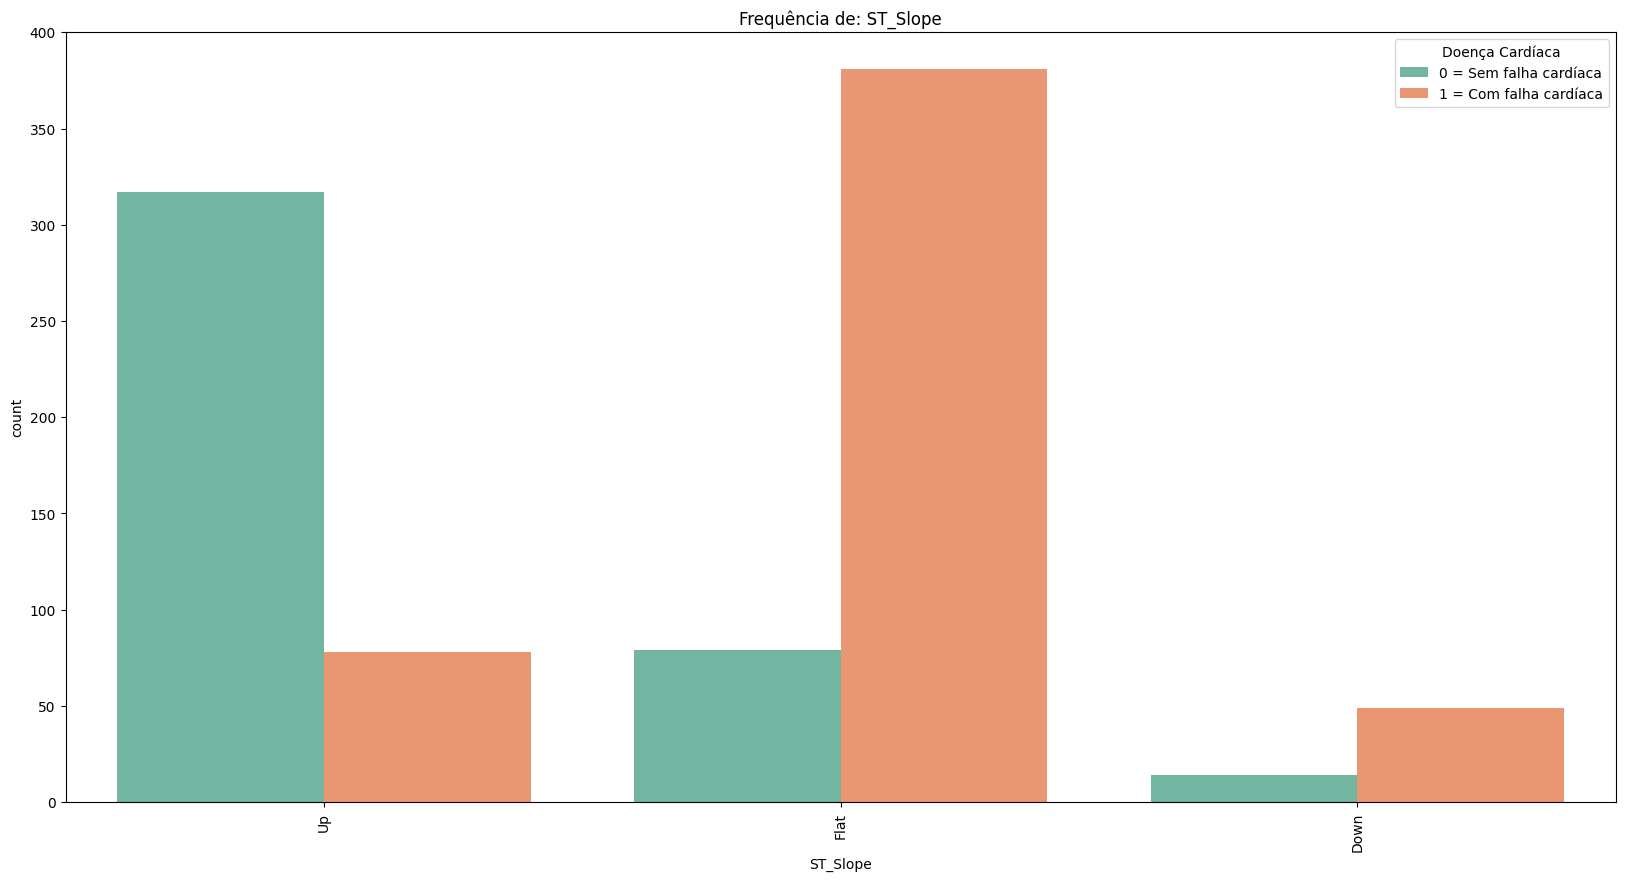

Frequência da coluna ST_Slope:
  ST_Slope  HeartDisease  Frequência
0     Down             0          14
1     Down             1          49
2     Flat             0          79
3     Flat             1         381
4       Up             0         317
5       Up             1          78


In [8]:
pular = ['Cholesterol', 'HeartDisease', 'MaxHR']

for col in df.columns:
    if col in pular:
        continue
    plt.figure(figsize=(20, 10))
    plt.title(f"Frequência de: {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Frequência")
    
    # Cria o gráfico countplot
    ax = sns.countplot(data=df, x=col, hue='HeartDisease', palette="Set2")
    plt.xticks(rotation=90)
    
    # Personaliza a legenda
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['0 = Sem falha cardíaca', '1 = Com falha cardíaca'], title='Doença Cardíaca')

    plt.show()  # Exibe o gráfico
    
    # Conta a frequência dos valores na coluna
    qtd = df.groupby([col, 'HeartDisease']).size().reset_index(name='Frequência')
    qtd
    
    # Imprime as frequências
    print(f'Frequência da coluna {col}:')
    print(qtd)


# Correlações entre as variáveis

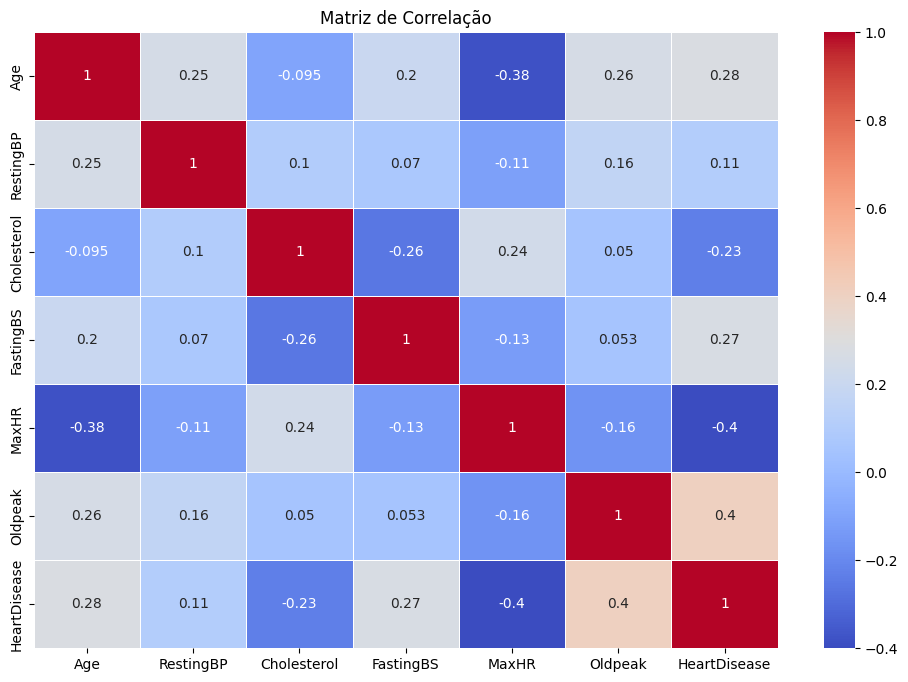

In [9]:
df_numeric = df.select_dtypes(include=[np.number])

# Calculando a matriz de correlação
corr_matrix = df_numeric.corr()

# Visualizando com um mapa de calor
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Matriz de Correlação")
plt.show()

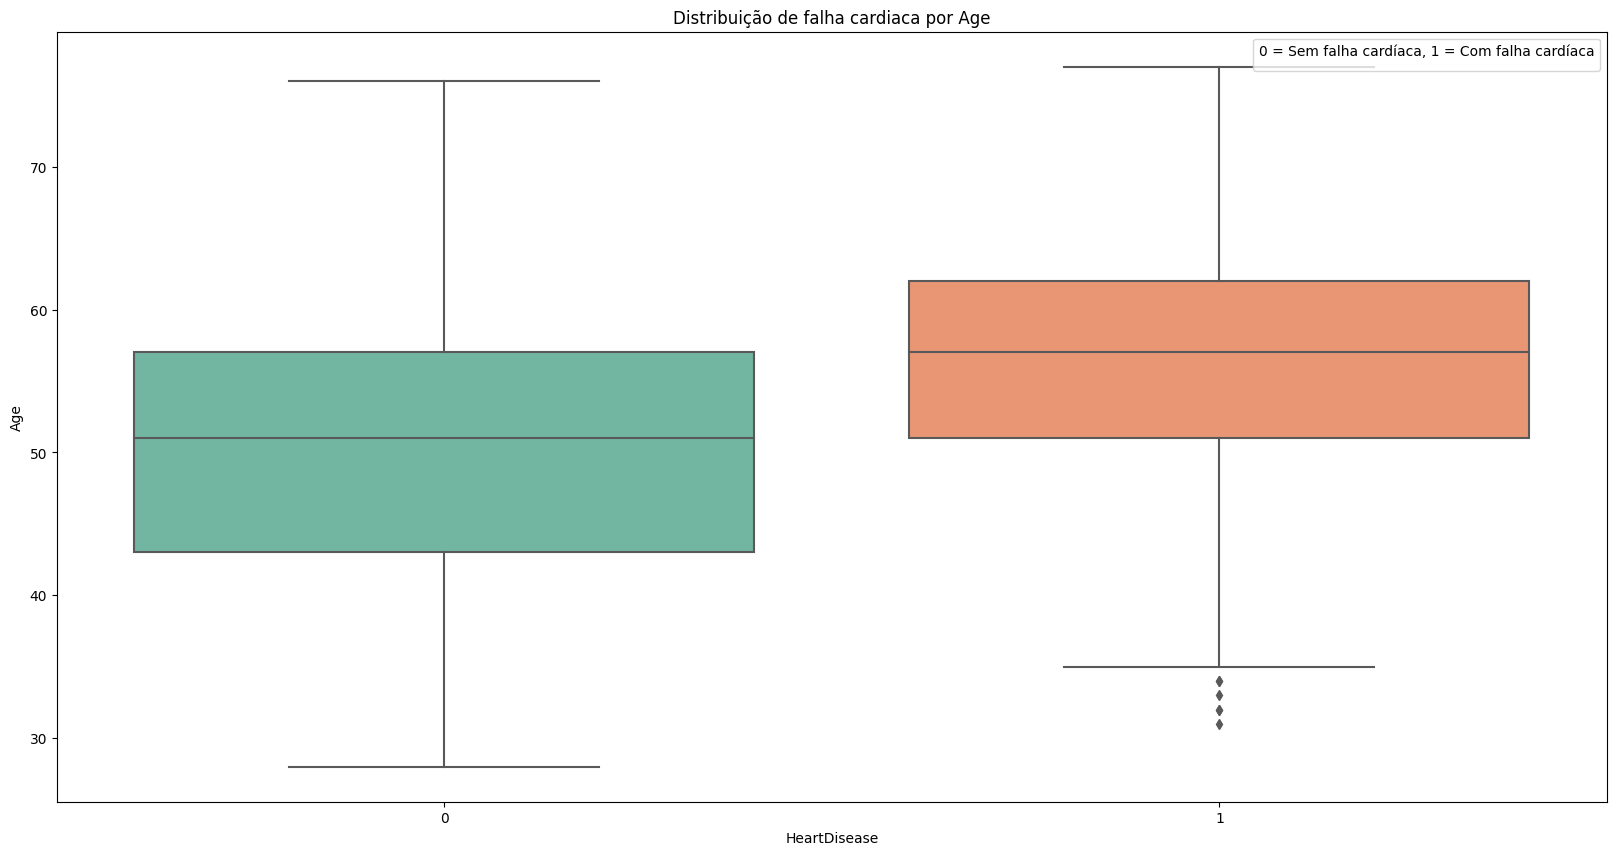

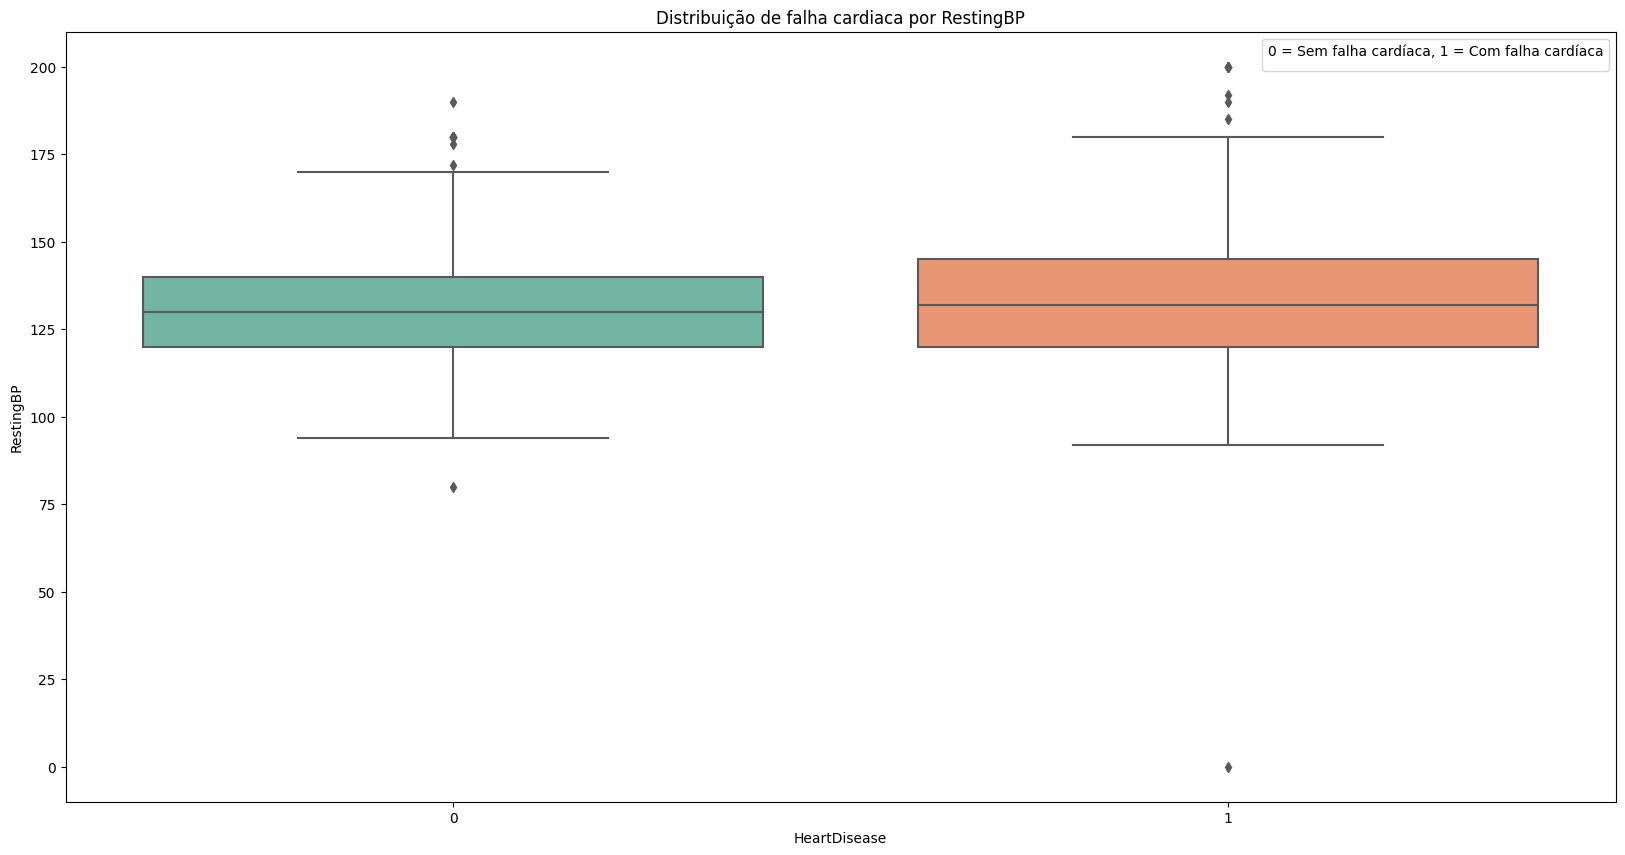

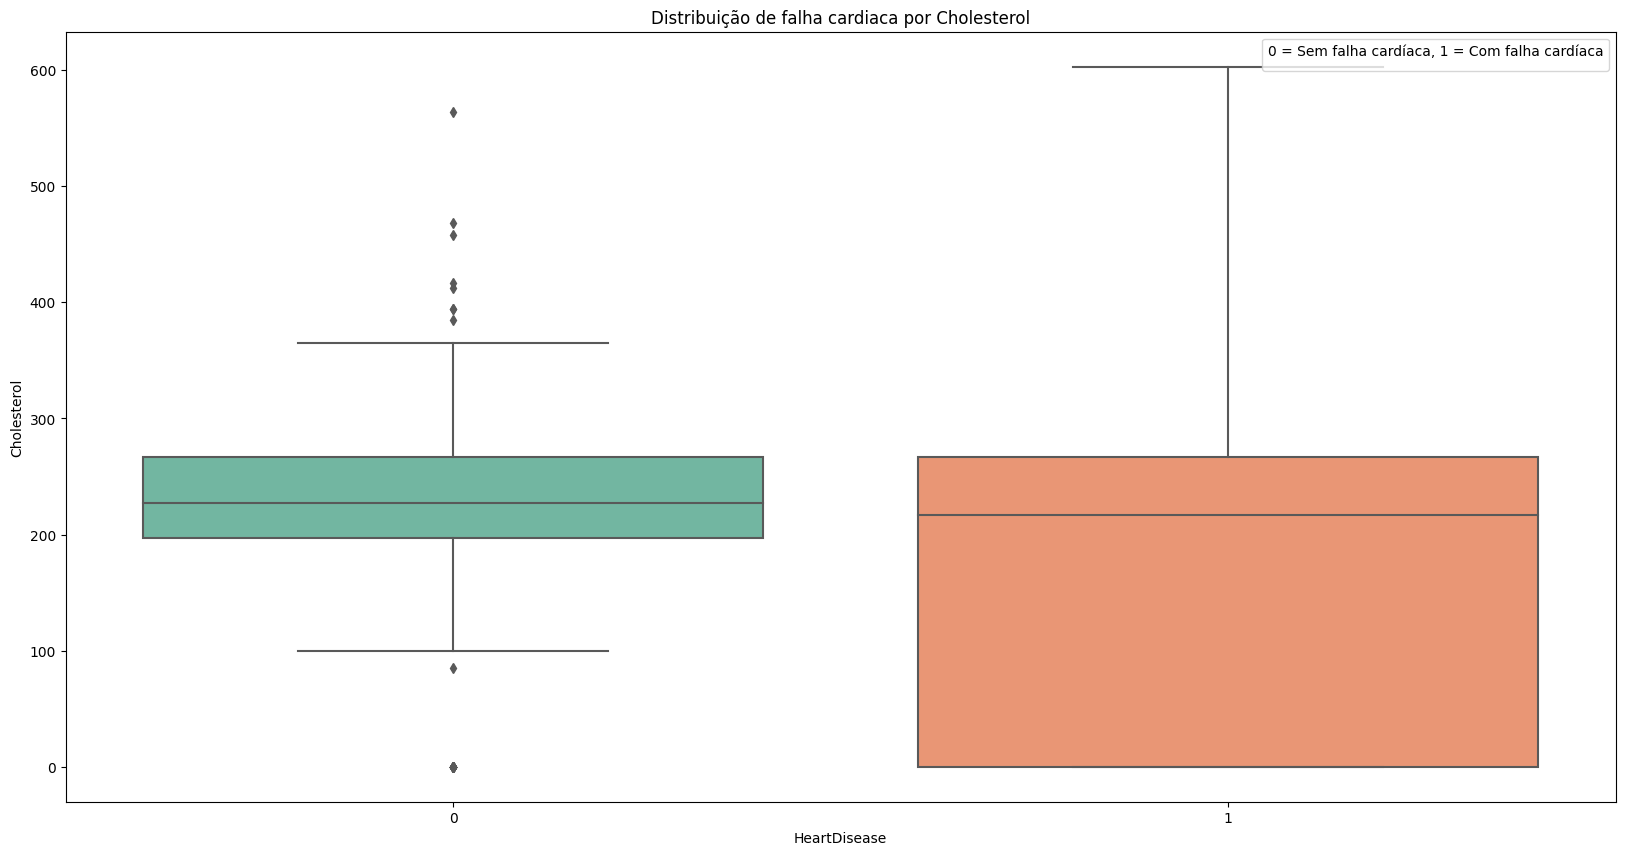

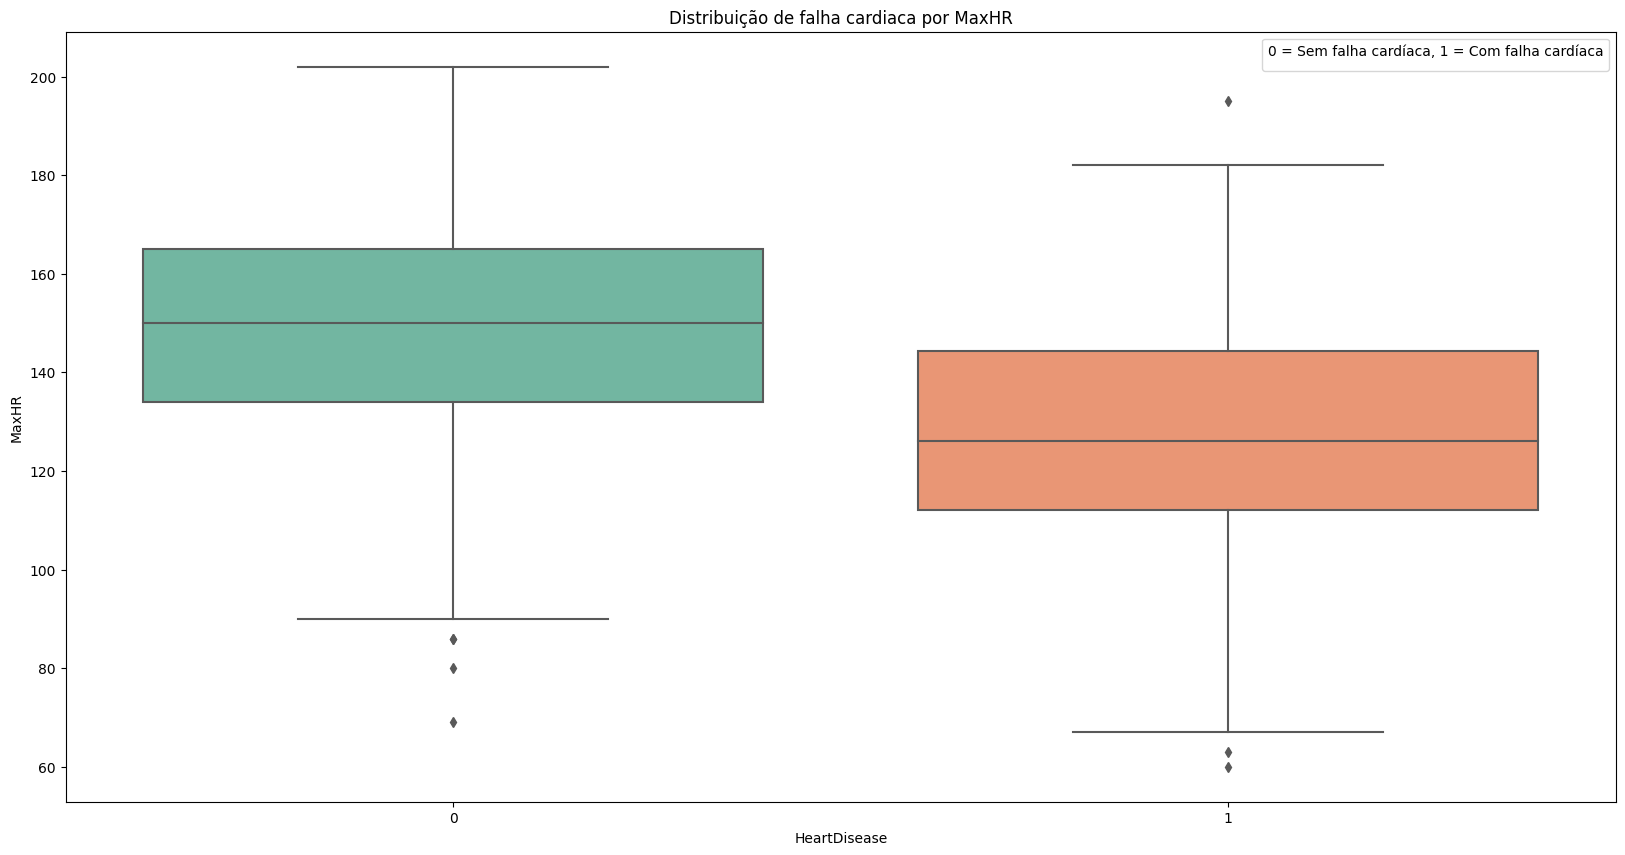

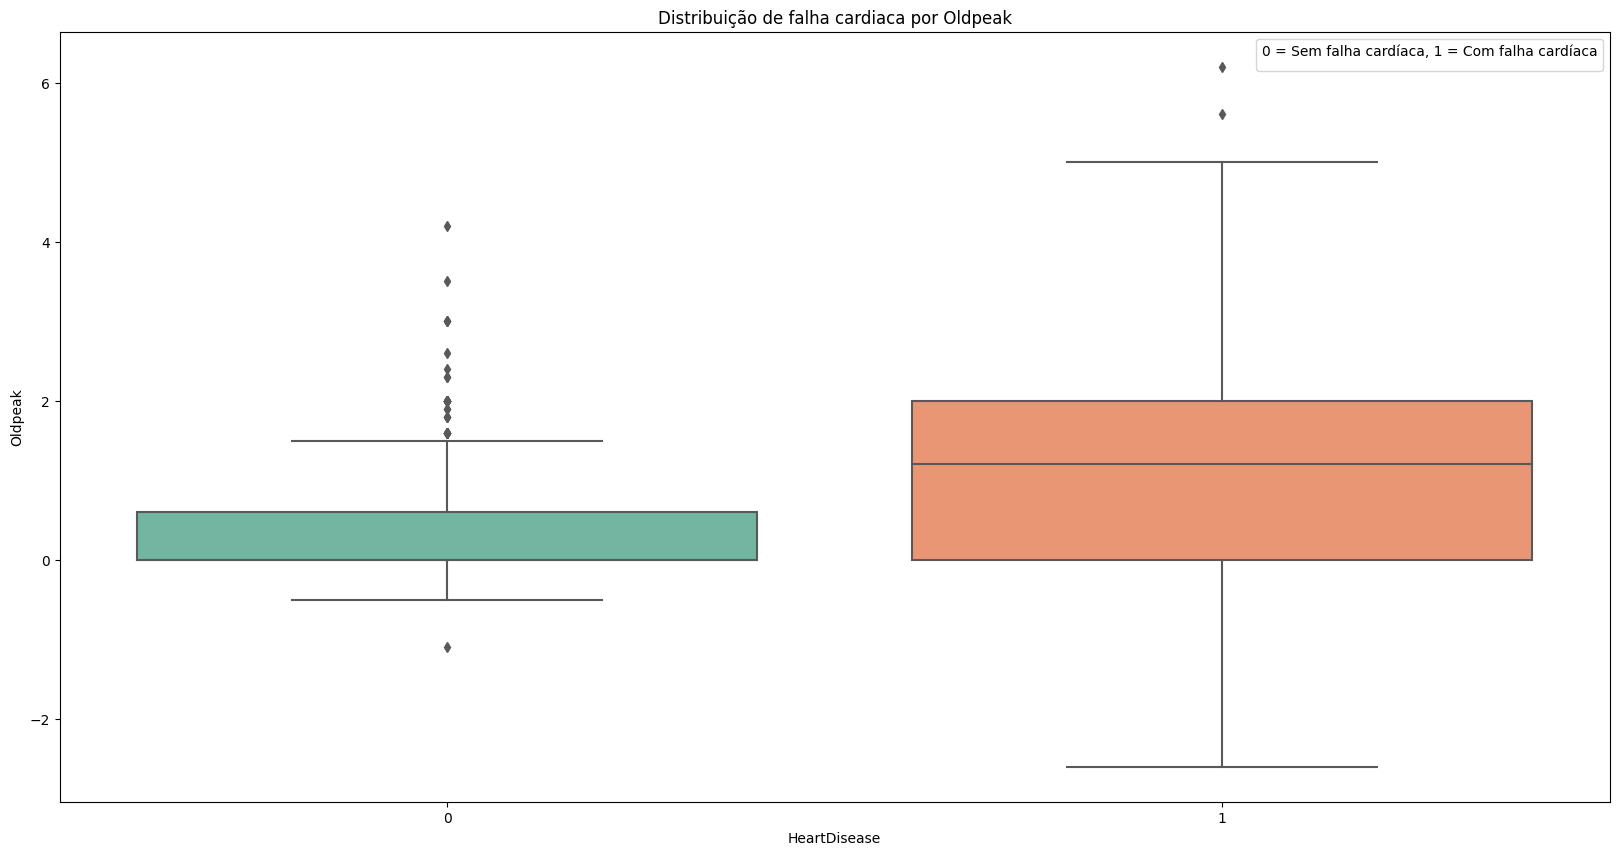

In [10]:
pular_box=['FastingBS','HeartDisease']
for col in col_num:
    if col in pular_box:
        continue
        
    plt.figure(figsize=(20, 10))
    plt.title(f"Distribuição de falha cardiaca por {col}")
    plt.xlabel(f"{col}")
    plt.legend(title="0 = Sem falha cardíaca, 1 = Com falha cardíaca", loc="upper right")   
    # Cria o gráfico countplot
    sns.boxplot(data=df, x='HeartDisease', y=col, palette="Set2")
    plt.xticks(rotation=0)

    plt.show()  # Exibe o gráfico

# Quantidade de pessoas com falhas cardiacas

In [11]:
# Contagem de valores da coluna target
contagem = df['HeartDisease'].value_counts()

# Exibindo os resultados
print("Contagem de falha cardíaca:")
print(f"Sem falha cardíaca (0): {contagem[0]}")
print(f"Com falha cardíaca (1): {contagem[1]}")

#Como a diferença entre as categorias é por volta de 10% vamos usar os dados dessa forma (com a diferença)

Contagem de falha cardíaca:
Sem falha cardíaca (0): 410
Com falha cardíaca (1): 508


# ML

In [12]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, make_scorer

In [13]:
# Aplicamos para todas as colunas categóricas no dataset
le = LabelEncoder()

for coluna in col_obj:
    df[coluna] = le.fit_transform(df[coluna])

In [14]:
# Separar as features (X) e o alvo (y)
X = df.drop('HeartDisease', axis=1)  # Features (todas as colunas, exceto 'rangetype')
y = df['HeartDisease']  # Variável alvo (rangetype)

# Dividir os dados em treino e teste (80% para treino e 20% para teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Definir a grade de parâmetros para o GridSearch
param_grid_rf = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2]
}

# Definir a grade de parâmetros para o GridSearch
param_grid_xgb = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

In [16]:
# 1. Random Forest
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),  # Normalização
    ('rf', RandomForestClassifier(random_state=42))
])
grid_search_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, n_jobs=-1, verbose=2)
grid_search_rf.fit(X_train, y_train)

# Melhor combinação de parâmetros
print(f"Melhores parâmetros Random Forest: {grid_search_rf.best_params_}")
y_pred_rf = grid_search_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Acurácia do modelo Random Forest: {accuracy_rf}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Melhores parâmetros Random Forest: {'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Acurácia do modelo Random Forest: 0.8858695652173914


In [17]:
# Passo 1: Recuperar os melhores parâmetros do GridSearch
melhores_parametros_rf = grid_search_rf.best_params_

# Passo 2: Remover o prefixo "rf__"
melhores_parametros_rf = {k.split('__')[1]: v for k, v in melhores_parametros_rf.items()}

# Passo 3: Criar o modelo com os melhores parâmetros
modelo_rf_final = RandomForestClassifier(**melhores_parametros_rf, random_state=42)

# Passo 4: Aplicar Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5 folds de validação cruzada
scores = cross_val_score(modelo_rf_final, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

# Passo 5: Exibir os resultados da Cross-Validation
print(f"Acurácia média do modelo Random Forest (CV): {scores.mean()}")
print(f"Desvio padrão da acurácia: {scores.std()}")

Acurácia média do modelo Random Forest (CV): 0.8681990971727253
Desvio padrão da acurácia: 0.0255959288100666


In [18]:
# 2. XGBoost
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),  # Normalização
    ('xgb', xgb.XGBClassifier(random_state=42))
])
grid_search_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=5, n_jobs=-1, verbose=2)
grid_search_xgb.fit(X_train, y_train)

# Melhor combinação de parâmetros
print(f"Melhores parâmetros XGBoost: {grid_search_xgb.best_params_}")
y_pred_xgb = grid_search_xgb.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Acurácia do modelo XGBoost: {accuracy_xgb}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Melhores parâmetros XGBoost: {'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}
Acurácia do modelo XGBoost: 0.8804347826086957


In [19]:
# Passo 1: Recuperar os melhores parâmetros do GridSearch
melhores_parametros_xgb = grid_search_xgb.best_params_

# Passo 2: Remover o prefixo "xgb__"
melhores_parametros_xgb = {k.split('__')[1]: v for k, v in melhores_parametros_xgb.items()}

# Passo 3: Criar o modelo com os melhores parâmetros
modelo_xgb_final = xgb.XGBClassifier(**melhores_parametros_xgb, random_state=42)

# Passo 4: Aplicar Cross-Validation
scores_xgb = cross_val_score(modelo_xgb_final, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

# Passo 5: Exibir os resultados
print(f"Acurácia média do modelo XGBoost (CV): {scores_xgb.mean()}")
print(f"Desvio padrão da acurácia: {scores_xgb.std()}")

Acurácia média do modelo XGBoost (CV): 0.86928011404134
Desvio padrão da acurácia: 0.0172048960669119
